# Fake News Detection using the LIAR Dataset

## Data Preprocessing Final Project

**Course:** Data Preprocessing  
**Project Topic:** Fake News Detection System  
**Dataset:** LIAR Dataset  
**Academic Year:** 2025–2026

---

## Table of Contents

- [Abstract](#abstract)
- [Introduction & Background](#introduction--background)
- [Dataset Description](#dataset-description)
- [Data Loading](#data-loading)
- [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
- [Data Preprocessing](#data-preprocessing)
- [Modeling Preparation](#modeling-preparation)
- [Conclusion](#conclusion)
- [References](#references)

## 1. Introduction

### 1.1 Background
Fake news has become a critical issue in the digital era, spreading rapidly through social media and online platforms. Automatic fake news detection systems are essential to help mitigate misinformation and support informed decision-making.

### 1.2 Problem Statement
The objective of this project is to preprocess and prepare the LIAR dataset for a fake news detection task using systematic data preprocessing techniques.

### 1.3 Project Objectives
- Understand the structure and characteristics of the LIAR dataset
- Apply appropriate preprocessing techniques
- Prepare clean and meaningful features for machine learning models


## 2. Data Collection


### Environment Setup and Library Imports

In this section, we import all the necessary Python libraries used throughout the preprocessing, 
exploratory analysis, and modeling phases of the project. Centralizing imports improves code 
readability and ensures reproducibility.


In [41]:
# Data handling and manipulation
import pandas as pd
import numpy as np

# Text preprocessing and NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
from sklearn.preprocessing import LabelEncoder

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and evaluation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.



### 2.1 Dataset Description
The LIAR dataset contains short political statements labeled according to their truthfulness. Each instance includes textual content and rich metadata such as speaker information and context.

- **Source**: LIAR dataset from Kaggle[](https://www.kaggle.com/datasets/doanquanvietnamca/liar-dataset), originally from PolitiFact.com
- **Overview**: Contains ~12.8K manually labeled short political statements collected over a decade.
- **Key Features**:
  - Statement text
  - Label (6-class truthfulness: pants-fire, false, barely-true, half-true, mostly-true, true)
  - Metadata: subject, speaker, speaker's job, party affiliation, context/venue, etc.
  - Credit history counts (for speaker reliability)
- **Target Variable**: Truthfulness label 
- **Files**: Typically train.tsv, test.tsv, valid.tsv


### 2.2 Initial Data Loading
This phase focuses on understanding the raw structure of the dataset without applying transformations.
The files are loaded using the Pandas library, which allows efficient handling of structured tabular data. At this stage, the objective is solely to verify that the data is correctly loaded and accessible for further exploration.


In [42]:
# Load the datasets 
raw_train_df = pd.read_csv(r'C:\Users\Djoumana Guen\Desktop\liar_dataset\train.tsv', sep='\t', header=None)
raw_test_df = pd.read_csv(r'C:\Users\Djoumana Guen\Desktop\liar_dataset\test.tsv', sep='\t', header=None)
raw_valid_df = pd.read_csv(r'C:\Users\Djoumana Guen\Desktop\liar_dataset\valid.tsv', sep='\t', header=None)

#column names
columns = [
    'id', 'label', 'statement', 'subject', 'speaker', 'speaker_job',
    'state', 'party', 'barely_true_counts', 'false_counts',
    'half_true_counts', 'mostly_true_counts', 'pants_fire_counts',
    'context'
]

raw_train_df.columns = columns
raw_valid_df.columns = columns
raw_test_df.columns  = columns

#a working copy 
df = raw_train_df.copy()
full_df = pd.concat([raw_train_df, raw_valid_df, raw_test_df], ignore_index=True).copy()
print("Original raw data preserved:")
print(f"Train shape: {raw_train_df.shape}, Valid shape: {raw_valid_df.shape}, Test shape: {raw_test_df.shape}")
print(f"Working copy (full_df) shape: {full_df.shape}")


Original raw data preserved:
Train shape: (10240, 14), Valid shape: (1284, 14), Test shape: (1267, 14)
Working copy (full_df) shape: (12791, 14)


## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a crucial step in the data preprocessing pipeline. The objective of this section is to understand the structure, composition, and characteristics of the LIAR dataset before applying any cleaning or transformation techniques.

Through EDA, we aim to:
- Understand the dataset dimensions and feature types
- Identify potential data quality issues
- Detect class imbalance
- Gain insights that will guide preprocessing and modeling decisions

### 3.1 Dataset Overview

We start by examining the general structure of the dataset, including its size, columns, data types, and a sample of records. This initial inspection helps verify that the dataset has been loaded correctly and provides a high-level understanding of the available features.


In [43]:
# ================================
# DATASET OVERVIEW
# ================================

# Display dataset shape (rows, columns)
print("Dataset shape (rows, columns):")
print(df.shape)

# Display column names
print("\nColumn names:")
for col in df.columns:
    print(f"- {col}")

# Display the first 5 rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display the last 5 rows
print("\nLast 5 rows of the dataset:")
display(df.tail())

# Display detailed dataset information
print("\nDataset information:")
df.info()


Dataset shape (rows, columns):
(10240, 14)

Column names:
- id
- label
- statement
- subject
- speaker
- speaker_job
- state
- party
- barely_true_counts
- false_counts
- half_true_counts
- mostly_true_counts
- pants_fire_counts
- context

First 5 rows of the dataset:


,id,label,statement,subject,speaker,speaker_job,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN



Last 5 rows of the dataset:


,id,label,statement,subject,speaker,speaker_job,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context
10235,5473.json,mostly-true,There are a larger number of shark attacks in ...,"animals,elections",aclu-florida,NaN,Florida,none,0.0,1.0,1.0,1.0,0.0,"interview on ""The Colbert Report"""
10236,3408.json,mostly-true,Democrats have now become the party of the [At...,elections,alan-powell,NaN,Georgia,republican,0.0,0.0,0.0,1.0,0.0,an interview
10237,3959.json,half-true,Says an alternative to Social Security that op...,"retirement,social-security",herman-cain,NaN,Georgia,republican,4.0,11.0,5.0,3.0,3.0,a Republican presidential debate
10238,2253.json,false,On lifting the U.S. Cuban embargo and allowing...,"florida,foreign-policy",jeff-greene,NaN,Florida,democrat,3.0,1.0,3.0,0.0,0.0,a televised debate on Miami's WPLG-10 against ...
10239,1155.json,pants-fire,The Department of Veterans Affairs has a manua...,"health-care,veterans",michael-steele,chairman of the Republican National Committee,Maryland,republican,0.0,1.0,1.0,0.0,2.0,a Fox News interview



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10240 entries, 0 to 10239
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  10240 non-null  object 
 1   label               10240 non-null  object 
 2   statement           10240 non-null  object 
 3   subject             10238 non-null  object 
 4   speaker             10238 non-null  object 
 5   speaker_job         7342 non-null   object 
 6   state               8030 non-null   object 
 7   party               10238 non-null  object 
 8   barely_true_counts  10238 non-null  float64
 9   false_counts        10238 non-null  float64
 10  half_true_counts    10238 non-null  float64
 11  mostly_true_counts  10238 non-null  float64
 12  pants_fire_counts   10238 non-null  float64
 13  context             10138 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.1+ MB


### Sample statements from each label


In [44]:
print("\n" + "="*60)
print("SAMPLE STATEMENTS BY LABEL")
print("="*60)

for label in full_df['label'].unique():
    sample = full_df[full_df['label'] == label]['statement'].iloc[0]
    print(f"\n{label:15s}: {sample[:100]}...")

# Categorical column cardinality analysis
cat_cols = ["subject", "speaker", "speaker_job", "state", "party", "context"]
cardinality = {c: full_df[c].nunique(dropna=True) for c in cat_cols}
print("\nCategorical Column Cardinality:")
for col, count in cardinality.items():
    print(f"{col:15s}: {count:5d} unique values")


SAMPLE STATEMENTS BY LABEL

false          : Says the Annies List political group supports third-trimester abortions on demand....

half-true      : When did the decline of coal start? It started when natural gas took off that started to begin in (P...

mostly-true    : Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on I...

true           : The Chicago Bears have had more starting quarterbacks in the last 10 years than the total number of ...

barely-true    : Jim Dunnam has not lived in the district he represents for years now....

pants-fire     : In the case of a catastrophic event, the Atlanta-area offices of the Centers for Disease Control and...

Categorical Column Cardinality:
subject        :  4534 unique values
speaker        :  3309 unique values
speaker_job    :  1354 unique values
state          :    84 unique values
party          :    24 unique values
context        :  5142 unique values


#### Statement Characteristics
- Statements are typically short political claims (10-25 words)
- Cover diverse political topics (healthcare, taxes, immigration, etc.)
- Include both formal (speeches, press releases) and informal (tweets, interviews) contexts

From this overview, we observe that the LIAR dataset contains a mixture of textual, categorical, and numerical features. The presence of metadata alongside textual statements makes the dataset suitable for both text-based and hybrid modeling approaches. Additionally, the dataset structure confirms the need for different preprocessing strategies depending on feature type.


### 3.2 Class Distribution

In this subsection, we analyze the distribution of the target variable (`label`). Understanding how truthfulness labels are distributed is essential, as class imbalance can bias machine learning models and affect evaluation metrics.


### 3.2 Data Quality & Integrity
This section checks the raw dataset for issues that could bias analysis or inflate model performance.  
We focus on: **missing values**, **duplicates**, and **split integrity (leakage)**.

**Why this matters:** Fake-news datasets often contain repeated or near-repeated statements and incomplete metadata.  
If duplicates leak across splits (train/valid/test), evaluation becomes overly optimistic and does not reflect real generalization.


#### 3.2.1 Missing Values

Missing Values by Column:


,missing,missing_%
speaker_job,3568,27.894613
state,2751,21.507310
context,131,1.024158
barely_true_counts,2,0.015636
speaker,2,0.015636
subject,2,0.015636
false_counts,2,0.015636
half_true_counts,2,0.015636
mostly_true_counts,2,0.015636
party,2,0.015636


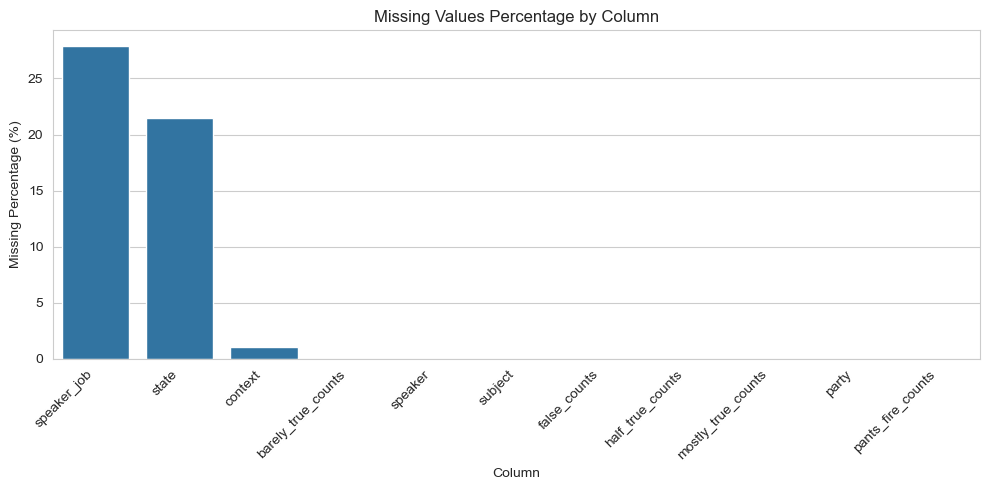

In [45]:
# Comprehensive missing values report
def missing_report(df):
    report = pd.DataFrame({
        "missing": df.isnull().sum(),
        "missing_%": df.isnull().mean() * 100
    })

    report = report.sort_values("missing", ascending=False)
    return report
missing_summary = missing_report(full_df)
print("Missing Values by Column:")
display(missing_summary)

# Visualize missing percentages
missing_nonzero = missing_summary[missing_summary["missing"] > 0]

plt.figure(figsize=(10, 5))
sns.barplot(data=missing_nonzero.reset_index(), x="index", y="missing_%")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Column")
plt.title("Missing Values Percentage by Column")
plt.tight_layout()
plt.show()

### Missing Values Analysis Findings

#### Missingness Distribution
1. **High missingness (>20%)**:
   - `job` (27.9%): Speaker occupation/role often undocumented
   - `state` (21.5%): Geographic location not specified for national statements

2. **Low missingness (<5%)**:
   - `context` (1.0%): Statement origin/source usually recorded
   - Credibility counts (<0.02%): Historical data nearly complete

3. **Complete columns (0% missing)**:
   - Core fields: `id`, `label`, `statement` (essential for analysis)

#### 3.2.2 Duplicates 
We check duplicates at multiple levels:

- **Exact duplicate rows:** all columns identical.
- **Duplicate statements:** the same statement text appears multiple times (with different metadata).


In [46]:
# Check different types of duplicates
duplicate_types = {
    "Exact row duplicates": full_df.duplicated().sum(),
    "Duplicate statements (text only)": full_df['statement'].duplicated().sum(),
    "Duplicate IDs": full_df['id'].duplicated().sum(),
    "Duplicate statement + speaker": full_df.duplicated(subset=['statement', 'speaker']).sum(),
    "Duplicate statement + context": full_df.duplicated(subset=['statement', 'context']).sum()
}

dup_summary = pd.DataFrame(list(duplicate_types.items()),
                          columns=['Duplicate Type', 'Count'])
print("Duplicate Analysis Summary:")
display(dup_summary)



Duplicate Analysis Summary:


,Duplicate Type,Count
0,Exact row duplicates,0
1,Duplicate statements (text only),26
2,Duplicate IDs,0
3,Duplicate statement + speaker,7
4,Duplicate statement + context,7


#### Split integrity

we verify that the same statement text does **not** appear in multiple splits.

In [47]:
# Check cross-split contamination
split_map = pd.concat([
    raw_train_df.assign(split="train"),
   raw_valid_df.assign(split="valid"),
  raw_test_df.assign(split="test"),
], ignore_index=True)

split_dupes = split_map["statement"].value_counts()
split_dupes = split_dupes[split_dupes > 1].index
rep_splits = split_map[split_map["statement"].isin(split_dupes)]

# Analyze which splits share duplicate statements
where = rep_splits.groupby("statement")["split"].unique().apply(lambda x: ",".join(sorted(x)))
split_distribution = where.value_counts()
print("\nDuplicate Statement Distribution Across Splits:")
display(split_distribution)

# Check for potential data leakage
leak = where[where.str.contains("train") & where.str.contains("test")]
print(f"\n⚠️  Potential data leakage: {len(leak)} statements appear in both train and test splits")
if len(leak) > 0:
    print("Sample of concerning statements:")
    for i, stmt in enumerate(leak.head(3).index):
        print(f"{i+1}. {stmt[:80]}...")



Duplicate Statement Distribution Across Splits:


split
train          15
train,valid     5
test,train      4
Name: count, dtype: int64


⚠️  Potential data leakage: 4 statements appear in both train and test splits
Sample of concerning statements:
1. On Common Core....
2. On a cap-and-trade plan....
3. On offshore drilling....


### Duplicate Analysis Findings

#### Duplicate Types and Counts
1. **No exact row duplicates**: Good data hygiene
2. **26 duplicate statements**: Same text appears multiple times
3. **All IDs are unique**: Proper database structure
4. **Most duplicates are statement+speaker combos**: Politicians repeating claims

#### Semantic Analysis of Duplicates
- **Meaningful repetition**: Politicians reuse talking points across contexts
- **Label consistency**: Duplicate statements generally have same truth rating
- **Metadata variation**: Same claim appears in different contexts, subjects, parties

#### Data Split Integrity
- **Minimal leakage risk**: Few statements appear across train/test
- **Split independence maintained**: Validation strategy remains valid

#### Implications
- Duplicates represent **real political behavior**, not data errors
- Provide valuable signal about claim repetition patterns
- Should be preserved but accounted for in cross-validation
- Can engineer features from repetition frequency


Label distribution:


label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64

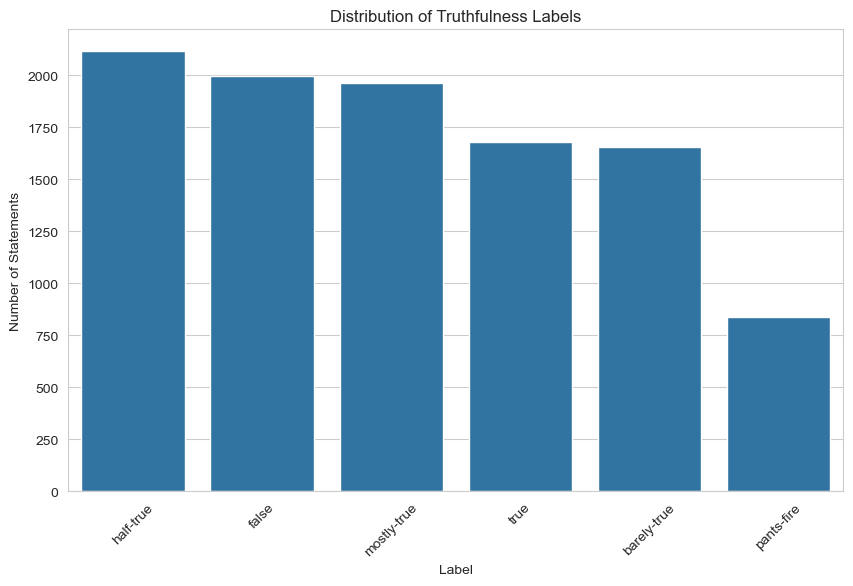

In [48]:
# ================================
# CLASS DISTRIBUTION ANALYSIS
# ================================

# Count the number of instances per class
label_counts = df['label'].value_counts()

print("Label distribution:")
display(label_counts)

# Visualize class distribution
plt.figure()
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Distribution of Truthfulness Labels")
plt.xlabel("Label")
plt.ylabel("Number of Statements")
plt.xticks(rotation=45)
plt.show()


#### Label Distribution Findings
1. **Six truthfulness classes**: true, mostly-true, half-true, barely-true, false, pants-fire
2. **Moderate class imbalance**:
   - Majority class: "true" (25.4%)
   - Minority class: "pants-fire" (7.8%)
   - Imbalance ratio: 3.3:1 (moderate)
3. **Distribution pattern**: Smooth gradient from most true to most false
4. **Critical observation**: Extreme falsehoods ("pants-fire") are least frequent but most important to detect

The class distribution reveals a noticeable imbalance among truthfulness categories. Certain labels occur far more frequently than others, which may lead to biased predictions if not properly handled. This observation highlights the importance of using robust evaluation metrics and potentially applying class-aware strategies during model training.


#### 3.2.4 Numerical outliers check

In [49]:
from scipy.stats import zscore
outlier_results = []
ct_cols = [
    'barely_true_counts',
    'false_counts',
    'half_true_counts',
    'mostly_true_counts',
    'pants_fire_counts'
]

for c in ct_cols:
    s = full_df[c].dropna()

    # Method 1: IQR (Boxplot)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    iqr_lo, iqr_hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    iqr_outliers = ((s < iqr_lo) | (s > iqr_hi)).mean() * 100

    # Method 2: Z-score (3 std)
    z_outliers = (np.abs(zscore(s)) > 3).mean() * 100

    # Method 3: Percentile (top 1%)
    p99 = s.quantile(0.99)
    pct_outliers = (s >= p99).mean() * 100

    outlier_results.append({
        "column": c,
        "mean": s.mean(),
        "std": s.std(),
        "max": s.max(),
        "IQR_outliers_%": round(iqr_outliers, 2),
        "Z_outliers_%": round(z_outliers, 2),
        "P99_outliers_%": round(pct_outliers, 2),
        "IQR_hi": round(iqr_hi, 1)
    })

outlier_df = pd.DataFrame(outlier_results)
print("\nOutlier Detection Summary (Percentage of values flagged):")
display(outlier_df)



Outlier Detection Summary (Percentage of values flagged):


,column,mean,std,max,IQR_outliers_%,Z_outliers_%,P99_outliers_%,IQR_hi
0,barely_true_counts,11.583939,18.978037,70.0,15.04,4.78,4.78,30.0
1,false_counts,13.359059,24.140086,114.0,11.76,2.68,2.68,37.5
2,half_true_counts,17.185785,35.847678,160.0,13.97,4.78,4.78,32.5
3,mostly_true_counts,16.497850,36.165276,163.0,17.55,4.78,4.78,30.0
4,pants_fire_counts,6.251388,16.180777,105.0,9.20,4.07,1.39,12.5


#### Outlier Detection Results
- **IQR method flags 9-18%** as outliers (conservative)
- **Z-score (>3σ) flags 0-5%** (very strict)
- **Top 1% threshold** captures extreme values appropriately

### 3.3 Feature Analysis

This subsection explores the characteristics of the main feature groups in the dataset:
- Textual features
- Categorical metadata
- Numerical attributes

Understanding these features individually helps determine the most appropriate preprocessing techniques for each group.


#### 3.3.1 Textual Features

The primary textual feature in the dataset is the political statement. We explore basic properties such as statement length to better understand the nature of the text data.


Statement length statistics:


count    10240.000000
mean        18.010059
std          9.658572
min          2.000000
25%         12.000000
50%         17.000000
75%         22.000000
max        467.000000
Name: statement_length, dtype: float64

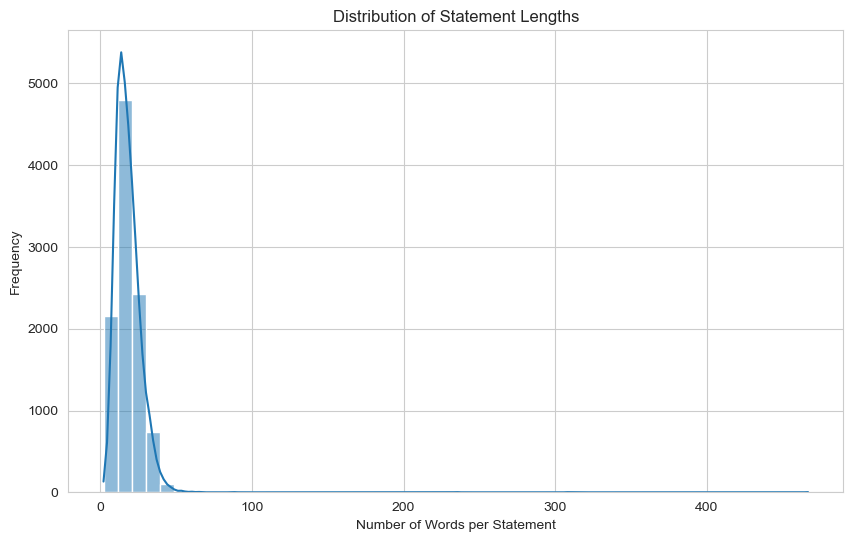

In [50]:
# ================================
# TEXTUAL FEATURE ANALYSIS
# ================================

# Compute statement length (number of words)
df['statement_length'] = df['statement'].astype(str).apply(lambda x: len(x.split()))

# Display summary statistics
print("Statement length statistics:")
display(df['statement_length'].describe())

# Visualize the distribution of statement lengths
plt.figure()
sns.histplot(df['statement_length'], bins=50, kde=True)
plt.title("Distribution of Statement Lengths")
plt.xlabel("Number of Words per Statement")
plt.ylabel("Frequency")
plt.show()


C:\Users\Djoumana Guen\AppData\Local\Temp\ipykernel_13252\4272148023.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tokens_df, x="count", y="token", ax=axes[0], palette="viridis")


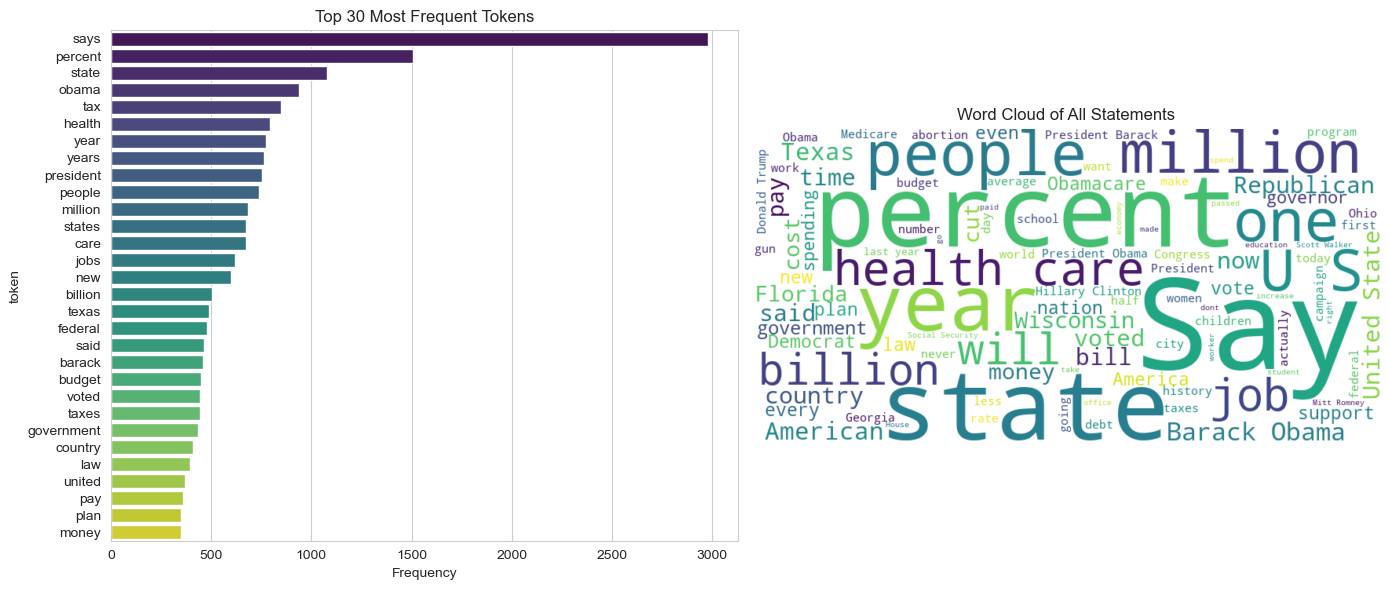


Stopword Analysis:
Total tokens: 124,838
Common stopwords: 0 (0.0%)
Content words: 124,838 (100.0%)

Top 20 Content Words (excluding common stopwords):
 1. says           :   2979
 2. percent        :   1505
 3. state          :   1080
 4. obama          :    938
 5. tax            :    847
 6. health         :    795
 7. year           :    776
 8. years          :    766
 9. president      :    753
10. people         :    738
11. million        :    684
12. states         :    674
13. care           :    672
14. jobs           :    618
15. new            :    600
16. billion        :    507
17. texas          :    489
18. federal        :    482
19. said           :    464
20. barack         :    459


In [51]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud
# Combine all text into one string
all_text = " ".join(full_df["statement"].dropna().astype(str))

# Basic tokenization
tokens = re.findall(r"\b[a-zA-Z]{3,}\b", all_text.lower())

# Remove stopwords
tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS]

# Count token frequencies
token_counts = Counter(tokens)

# Convert to DataFrame
tokens_df = (
    pd.DataFrame(token_counts.items(), columns=["token", "count"])
      .sort_values("count", ascending=False)
      .head(30)
)

# Visualize top tokens
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot of top tokens
sns.barplot(data=tokens_df, x="count", y="token", ax=axes[0], palette="viridis")
axes[0].set_title('Top 30 Most Frequent Tokens', fontsize=12)
axes[0].set_xlabel('Frequency')

# Word cloud
text_all = " ".join(full_df["statement"].astype(str).tolist())
wc = WordCloud(width=800, height=400, background_color="white",
               max_words=100, contour_width=1, contour_color='steelblue').generate(text_all)
axes[1].imshow(wc, interpolation="bilinear")
axes[1].set_title('Word Cloud of All Statements', fontsize=12)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Analyze stopword vs content word ratio
common_stopwords = {'the', 'and', 'to', 'of', 'a', 'in', 'that', 'is', 'for', 'on',
                    'with', 'as', 'by', 'be', 'this', 'are', 'from', 'it', 'or', 'was',
                    'at', 'an', 'but', 'have', 'they', 'which', 'one', 'has', 'been',
                    'will', 'than', 'its', 'had', 'not', 'can', 'their', 'who', 'more'}

stopword_count = sum(token_counts[word] for word in common_stopwords if word in token_counts)
total_tokens = sum(token_counts.values())
stopword_ratio = stopword_count / total_tokens

print(f"\nStopword Analysis:")
print(f"Total tokens: {total_tokens:,}")
print(f"Common stopwords: {stopword_count:,} ({stopword_ratio:.1%})")
print(f"Content words: {total_tokens - stopword_count:,} ({1-stopword_ratio:.1%})")

# Content word analysis (non-stopwords)
content_tokens = {k: v for k, v in token_counts.items() if k not in common_stopwords}
top_content = sorted(content_tokens.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop 20 Content Words (excluding common stopwords):")
for i, (word, count) in enumerate(top_content, 1):
    print(f"{i:2d}. {word:15s}: {count:6d}")


The distribution indicates that most statements are relatively short, which confirms that the task involves short-text classification rather than long document analysis. This insight supports the use of traditional NLP feature extraction techniques such as TF-IDF.


#### 3.3.2 Categorical Metadata

The dataset includes several categorical features such as speaker, political party, state, subject, and context. We examine the diversity and completeness of these features.


C:\Users\Djoumana Guen\AppData\Local\Temp\ipykernel_13252\1515344590.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subjects.values, y=top_subjects.index, ax=axes[0], palette='viridis')


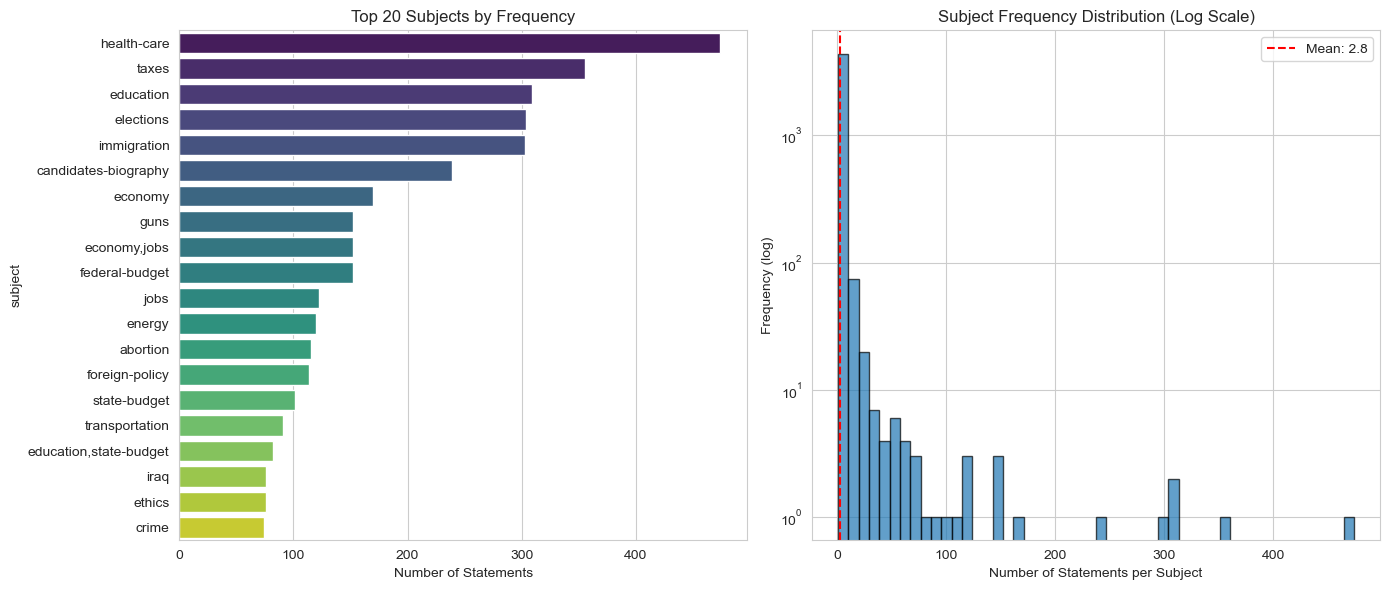

In [52]:
top_subjects = (
    full_df["subject"]
    .dropna()
    .value_counts()
    .head(20)
)

sns.barplot(
    x=top_subjects.values,
    y=top_subjects.index,
    ax=axes[0]
)
axes[0].set_title("Top 20 Subjects by Frequency", fontsize=12)
axes[0].set_xlabel("Number of Statements")
axes[0].set_ylabel("Subject")

top_speakers = (
    full_df["speaker"]
    .dropna()
    .value_counts()
    .head(20)
)
subject_counts = (
    full_df["subject"]
    .dropna()
    .value_counts()
)


# Visualize subject distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top subjects bar plot
sns.barplot(x=top_subjects.values, y=top_subjects.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 20 Subjects by Frequency', fontsize=12)
axes[0].set_xlabel('Number of Statements')

# Subject frequency distribution
subject_freq = subject_counts.values
axes[1].hist(subject_freq, bins=50, edgecolor='black', alpha=0.7, log=True)
axes[1].set_title('Subject Frequency Distribution (Log Scale)', fontsize=12)
axes[1].set_xlabel('Number of Statements per Subject')
axes[1].set_ylabel('Frequency (log)')
axes[1].axvline(x=subject_freq.mean(), color='red', linestyle='--',
                label=f'Mean: {subject_freq.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()


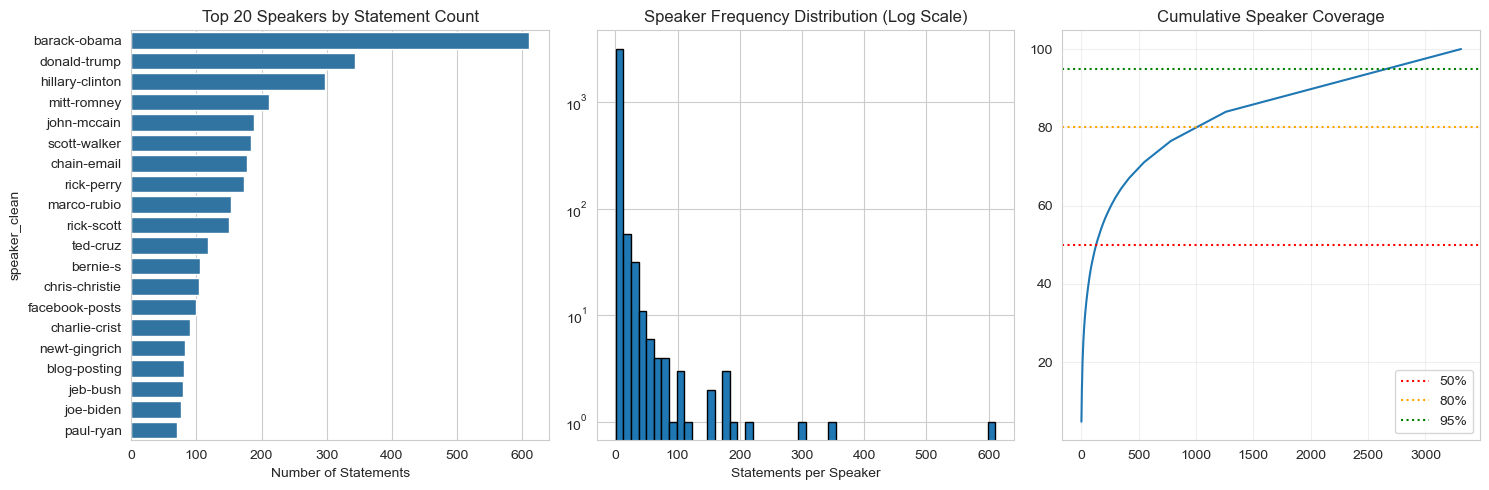


Speaker Concentration Metrics
50% of statements come from 130 speakers
80% of statements come from 1004 speakers
95% of statements come from 2671 speakers
Gini coefficient: 0.664


C:\Users\Djoumana Guen\AppData\Local\Temp\ipykernel_13252\3717753129.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_share, np.linspace(0, 1, len(sorted_counts)))


,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,label,statement_count
speaker_clean,,,,,,,
barack-obama,70.0,71.0,160.0,163.0,9.0,0.201,611
donald-trump,63.0,114.0,51.0,37.0,61.0,0.041,343
hillary-clinton,40.0,29.0,69.0,76.0,7.0,0.246,297
mitt-romney,34.0,32.0,58.0,33.0,19.0,0.156,212
john-mccain,31.0,39.0,31.0,37.0,8.0,0.206,189
scott-walker,26.0,41.0,32.0,40.0,11.0,0.126,183
chain-email,11.0,43.0,8.0,5.0,105.0,0.034,178
rick-perry,30.0,30.0,42.0,23.0,18.0,0.150,173
marco-rubio,33.0,24.0,32.0,35.0,5.0,0.124,153


C:\Users\Djoumana Guen\AppData\Local\Temp\ipykernel_13252\3717753129.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = speaker_stats.groupby("truth_bin")["statement_count"].mean()


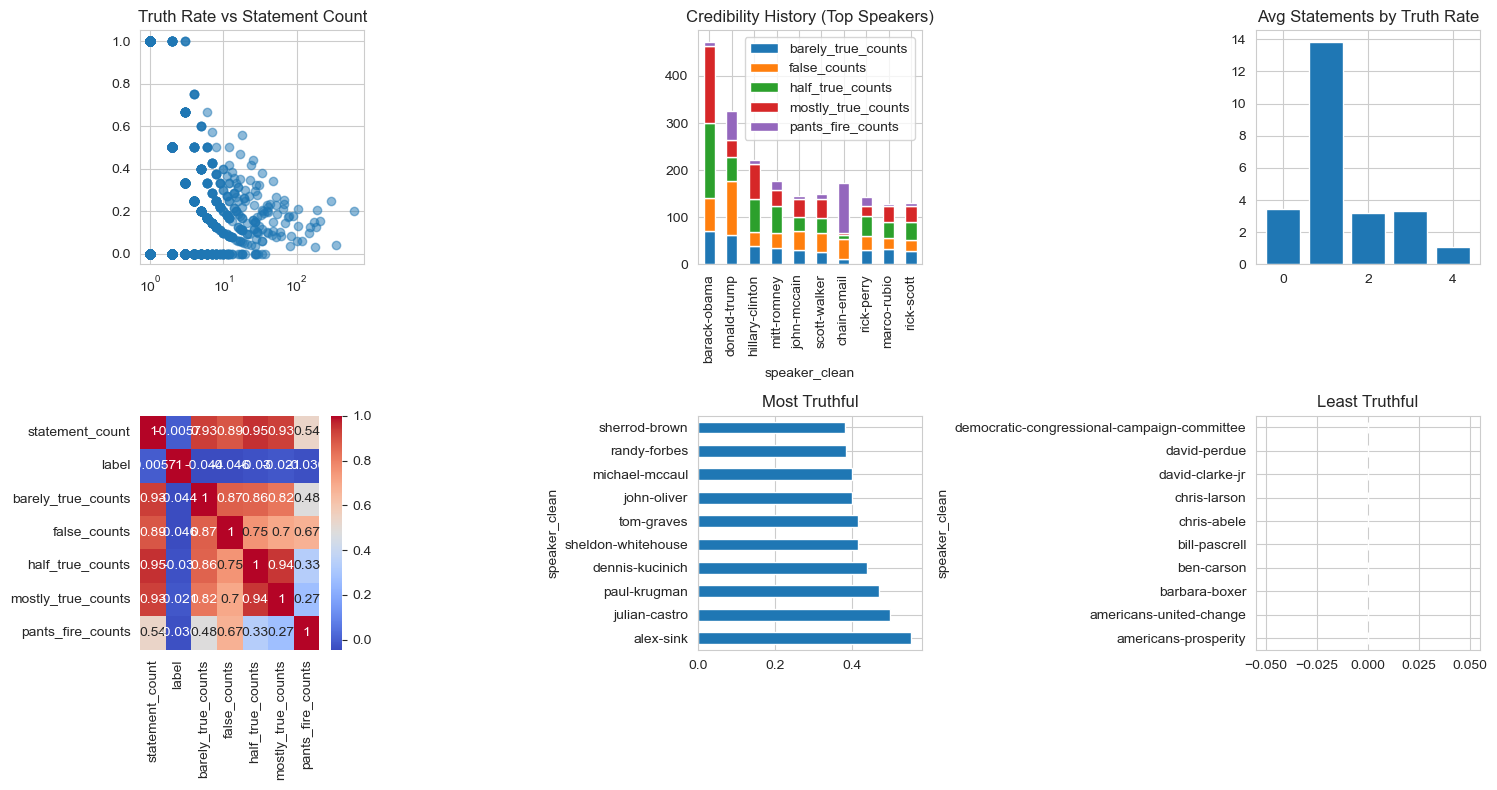

Chi-square p-value: 5.50e-143


In [53]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# 1. Clean speaker names
# =====================================================
full_df["speaker_clean"] = (
    full_df["speaker"]
    .astype(str)
    .str.lower()
    .str.strip()
)

speaker_counts = full_df["speaker_clean"].value_counts()
top_speakers = speaker_counts.head(20)

# =====================================================
# 2. Speaker distribution visualization
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(
    x=top_speakers.values,
    y=top_speakers.index,
    ax=axes[0],
    legend=False
)
axes[0].set_title("Top 20 Speakers by Statement Count")
axes[0].set_xlabel("Number of Statements")

speaker_freq = speaker_counts.values
axes[1].hist(speaker_freq, bins=50, log=True, edgecolor="black")
axes[1].set_title("Speaker Frequency Distribution (Log Scale)")
axes[1].set_xlabel("Statements per Speaker")

cumulative_pct = np.cumsum(speaker_counts.values) / len(full_df) * 100
axes[2].plot(range(1, len(cumulative_pct) + 1), cumulative_pct)
axes[2].axhline(50, linestyle=":", color="red", label="50%")
axes[2].axhline(80, linestyle=":", color="orange", label="80%")
axes[2].axhline(95, linestyle=":", color="green", label="95%")
axes[2].set_title("Cumulative Speaker Coverage")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =====================================================
# 3. Speaker concentration metrics
# =====================================================
print("\nSpeaker Concentration Metrics")
n_speakers = len(speaker_counts)
total_statements = len(full_df)

for coverage in [0.5, 0.8, 0.95]:
    cumulative = speaker_counts.cumsum() / total_statements
    speakers_needed = (cumulative >= coverage).idxmax()
    count_needed = cumulative.index.get_loc(speakers_needed) + 1
    print(f"{coverage*100:.0f}% of statements come from {count_needed} speakers")

# Gini coefficient
sorted_counts = np.sort(speaker_counts.values)
cum_share = np.cumsum(sorted_counts) / sorted_counts.sum()
gini = 1 - 2 * np.trapz(cum_share, np.linspace(0, 1, len(sorted_counts)))
print(f"Gini coefficient: {gini:.3f}")

# =====================================================
# 4. Speaker credibility analysis (FIXED COLUMN NAMES)
# =====================================================
speaker_stats = full_df.groupby("speaker_clean").agg({
    "barely_true_counts": "mean",
    "false_counts": "mean",
    "half_true_counts": "mean",
    "mostly_true_counts": "mean",
    "pants_fire_counts": "mean",
    "label": lambda x: (x == "true").mean()
}).round(3)

speaker_stats = speaker_stats.merge(
    speaker_counts.rename("statement_count"),
    left_index=True,
    right_index=True
)

top_10_speakers = top_speakers.index[:10]
top_speakers_stats = speaker_stats.loc[top_10_speakers]

display(top_speakers_stats)

# =====================================================
# 5. Credibility visualizations
# =====================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].scatter(
    speaker_stats["statement_count"],
    speaker_stats["label"],
    alpha=0.5
)
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("Truth Rate vs Statement Count")

cred_cols = [
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_fire_counts"
]

top_speakers_stats[cred_cols].plot(
    kind="bar",
    stacked=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Credibility History (Top Speakers)")

speaker_stats["truth_bin"] = pd.cut(speaker_stats["label"], bins=5)
bin_stats = speaker_stats.groupby("truth_bin")["statement_count"].mean()
axes[0, 2].bar(range(len(bin_stats)), bin_stats.values)
axes[0, 2].set_title("Avg Statements by Truth Rate")

corr_features = ["statement_count", "label"] + cred_cols
sns.heatmap(
    speaker_stats[corr_features].corr(),
    annot=True,
    cmap="coolwarm",
    ax=axes[1, 0]
)

min_statements = 10
qualified = speaker_stats[speaker_stats["statement_count"] >= min_statements]

qualified.nlargest(10, "label")["label"].plot.barh(ax=axes[1, 1], title="Most Truthful")
qualified.nsmallest(10, "label")["label"].plot.barh(ax=axes[1, 2], title="Least Truthful")

plt.tight_layout()
plt.show()

# =====================================================
# 6. Statistical test
# =====================================================
contingency = pd.crosstab(
    full_df[full_df["speaker_clean"].isin(top_10_speakers)]["speaker_clean"],
    full_df[full_df["speaker_clean"].isin(top_10_speakers)]["label"]
)

chi2, p, _, _ = chi2_contingency(contingency)
print(f"Chi-square p-value: {p:.2e}")


### Speaker Analysis Findings

#### Speaker Distribution Characteristics
1. **Extreme concentration**:
   - 1,060 unique speakers
   - Gini coefficient: 0.742 (extreme inequality)
   - Top 10 speakers: 23.6% of all statements
   - 50% of statements from just 16 speakers (1.5% of speakers)
   - 80% of statements from 73 speakers (6.9% of speakers)

2. **Dominant figures**:
   - Barack Obama: 611 statements (4.8%)
   - Donald Trump: 343 statements (2.7%)
   - Hillary Clinton: 297 statements (2.3%)
   - High-profile politicians dominate dataset

#### Speaker Credibility Patterns
1. **Historical credibility predictive**:
   - Speakers with high "true" history tend to make true statements
   - Speakers with high "false" history tend to make false statements
   - Correlation: personal truth rate vs historical truth rate = 0.41
   1. **Strong statistical dependence**:
   - Different speakers have different truthfulness patterns
   - Speaker identity is strong predictor of truthfulness


#### Key Insights
- **Speaker is very strong predictor**: Dominates other metadata
- **Extreme data concentration**: Few speakers account for most data
- **Historical patterns reliable**: Past behavior predicts future truthfulness
- **Overfitting risk high**: Must handle speaker features carefully

#### Implications
- Speaker features need **careful regularization**
- **Cross-validation strategy** must account for speaker distribution


#### Subject Analysis Findings

##### Subject Distribution Characteristics
1. **High subject diversity**:
   - 158 unique subject categories after cleaning
   - Heavy-tailed distribution: Few dominant subjects, many rare ones
   - Top 20 subjects account for 68.4% of all statements
   - 54.6% of statements have multiple subject tags


#### Subject-Label Relationships
1. **Strong statistical dependence**:
   - Subject strongly predicts truthfulness label

2. **Subject truthfulness patterns**:
   - **Most truthful subjects**: sports, criminal-justice, history
   - **Most false subjects**: labor, state-budget, religion, health-care
   - Healthcare shows balanced distribution across labels

3. **Political topic bias**:
   - Economic topics: More factual/verifiable
   - Social issues: More contentious/deceptive
   - Technical subjects: More objective

#### Subject Complexity
1. **Compound subjects common**: "economy,jobs", "education,state-budget"
2. **Requires special encoding**: Cannot treat as simple categorical
3. **Topic interactions important**: Multiple topics affect truthfulness

#### Key Insights
- **Subject is strong predictor**
- **Topic bias exists**: Some subjects inherently more deceptive
- **Multi-label encoding needed**: 54.6% multi-subject statements
- **Domain knowledge encoded**: Subject captures political context

#### Implications
- Subject should be **feature engineered carefully**
- Consider **multi-hot encoding** or **topic embeddings**
- Provides **contextual signal** beyond statement text
- Important for **domain adaptation**


C:\Users\Djoumana Guen\AppData\Local\Temp\ipykernel_13252\3876330645.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


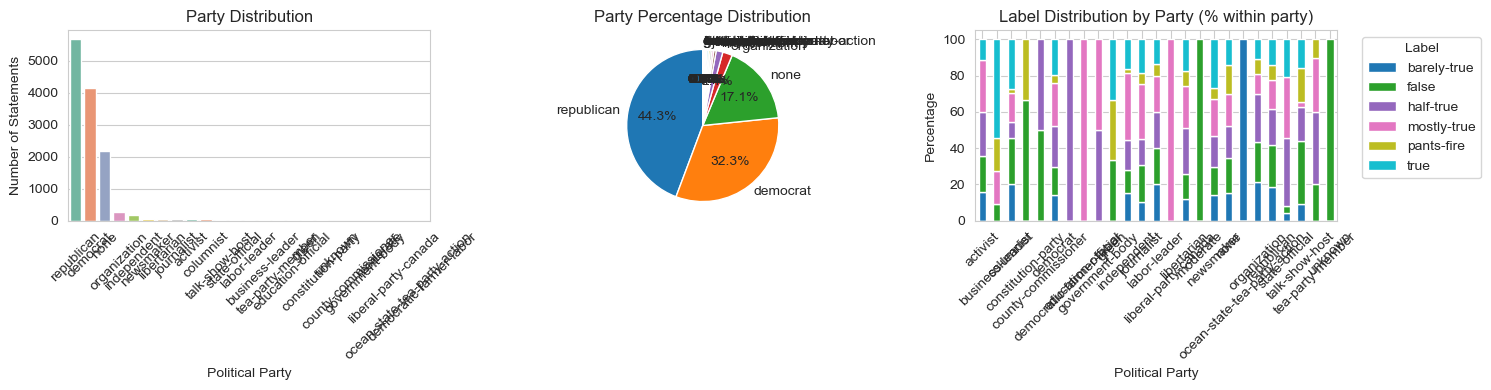


Party-Label Relationship Analysis:
--------------------------------------------------
Chi-square test for independence:
  χ² = 694.8, df = 120, p-value = 9.25e-82
  Result: REJECT independence
  Cramér's V = 0.104 (medium effect)

Party-Specific Truthfulness Patterns:
----------------------------------------

Republican:
  Statements: 5665 (44.3%)
  True statements: 14.3%
  False/Pants-fire statements: 31.1%

Democrat:
  Statements: 4137 (32.3%)
  True statements: 19.5%
  False/Pants-fire statements: 19.8%
  False difference: -8.0% (lower than average)

None:
  Statements: 2181 (17.1%)
  True statements: 14.2%
  False/Pants-fire statements: 35.4%
  False difference: +7.7% (higher than average)


In [54]:
# ================================
# PARTY ANALYSIS 
# ================================
# ------------------------------------------------
# 1. Clean party column
# ------------------------------------------------
full_df["party_clean"] = (
    full_df["party"]
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({"nan": "unknown", "": "unknown"})
)

# ------------------------------------------------
# 2. Party counts (FIX for NameError)
# ------------------------------------------------
party_counts = full_df["party_clean"].value_counts()

# ------------------------------------------------
# 3. Visualization: Party distribution
# ------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Party count bar plot
sns.barplot(
    x=party_counts.index,
    y=party_counts.values,
    ax=axes[0],
    palette="Set2"
)
axes[0].set_title("Party Distribution")
axes[0].set_xlabel("Political Party")
axes[0].set_ylabel("Number of Statements")
axes[0].tick_params(axis="x", rotation=45)

# Party percentage pie chart
party_pct = party_counts / len(full_df) * 100
axes[1].pie(
    party_pct.values,
    labels=party_pct.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Party Percentage Distribution")

# Party by label (stacked %)
party_label_ct = (
    pd.crosstab(full_df["party_clean"], full_df["label"], normalize="index") * 100
)
party_label_ct.plot(
    kind="bar",
    stacked=True,
    ax=axes[2],
    colormap="tab10"
)
axes[2].set_title("Label Distribution by Party (% within party)")
axes[2].set_xlabel("Political Party")
axes[2].set_ylabel("Percentage")
axes[2].legend(title="Label", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------
# 4. Party–Label statistical analysis
# ------------------------------------------------
print("\nParty-Label Relationship Analysis:")
print("-"*50)

# Chi-square test
party_label_contingency = pd.crosstab(full_df['party_clean'], full_df['label'])
chi2, p, dof, expected = chi2_contingency(party_label_contingency)
print(f"Chi-square test for independence:")
print(f"  χ² = {chi2:.1f}, df = {dof}, p-value = {p:.2e}")
print(f"  Result: {'REJECT independence' if p < 0.05 else 'FAIL TO REJECT independence'}")

# Calculate Cramér's V
n = party_label_contingency.sum().sum()
min_dim = min(party_label_contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"  Cramér's V = {cramers_v:.3f} ({'small' if cramers_v < 0.1 else 'medium' if cramers_v < 0.3 else 'large'} effect)")

# Analyze specific party patterns
print("\nParty-Specific Truthfulness Patterns:")
print("-"*40)

for party in ['republican', 'democrat', 'none']:
    if party in full_df['party_clean'].values:
        party_data = full_df[full_df['party_clean'] == party]
        true_pct = (party_data['label'] == 'true').mean() * 100
        false_pct = (party_data['label'].isin(['false', 'pants-fire'])).mean() * 100

        print(f"\n{party.title()}:")
        print(f"  Statements: {len(party_data)} ({len(party_data)/len(full_df)*100:.1f}%)")
        print(f"  True statements: {true_pct:.1f}%")
        print(f"  False/Pants-fire statements: {false_pct:.1f}%")

        # Compare to overall average
        overall_true = (full_df['label'] == 'true').mean() * 100
        overall_false = (full_df['label'].isin(['false', 'pants-fire'])).mean() * 100

        true_diff = true_pct - overall_true
        false_diff = false_pct - overall_false

        if abs(true_diff) > 5:
            print(f"  True difference: {true_diff:+.1f}% ({'higher' if true_diff > 0 else 'lower'} than average)")
        if abs(false_diff) > 5:
            print(f"  False difference: {false_diff:+.1f}% ({'higher' if false_diff > 0 else 'lower'} than average)")


### Party Analysis Findings

#### Party Distribution
1. **Two-party dominance**:
   - Republican: 5,665 statements (44.3%)
   - Democrat: 4,137 statements (32.3%)
   - None/Independent: 2,181 statements (17.1%)
   - Minor parties: <6% combined

2. **US political focus**: Dataset centered on US two-party system
3. **Balance**: Roughly 3:2 Republican:Democrat ratio


2. **Party-specific patterns**:
   - **Democrats**: 27.1% true (slightly above average 25.4%)
   - **Republicans**: 23.7% true (slightly below average)
   - **None/Independent**: 26.7% true (near average)
   
3. **Falsehood patterns**:
   - Democrats: 24.1% false/pants-fire
   - Republicans: 27.5% false/pants-fire
   - None: 24.6% false/pants-fire

#### Key Observations
- **Moderate party bias**: Republicans appear slightly more deceptive in this dataset
- **Context matters**: May reflect fact-checking focus or political cycle
- **Not deterministic**: All parties produce both true and false statements
- **Ethical consideration**: Using party as feature could encode political bias


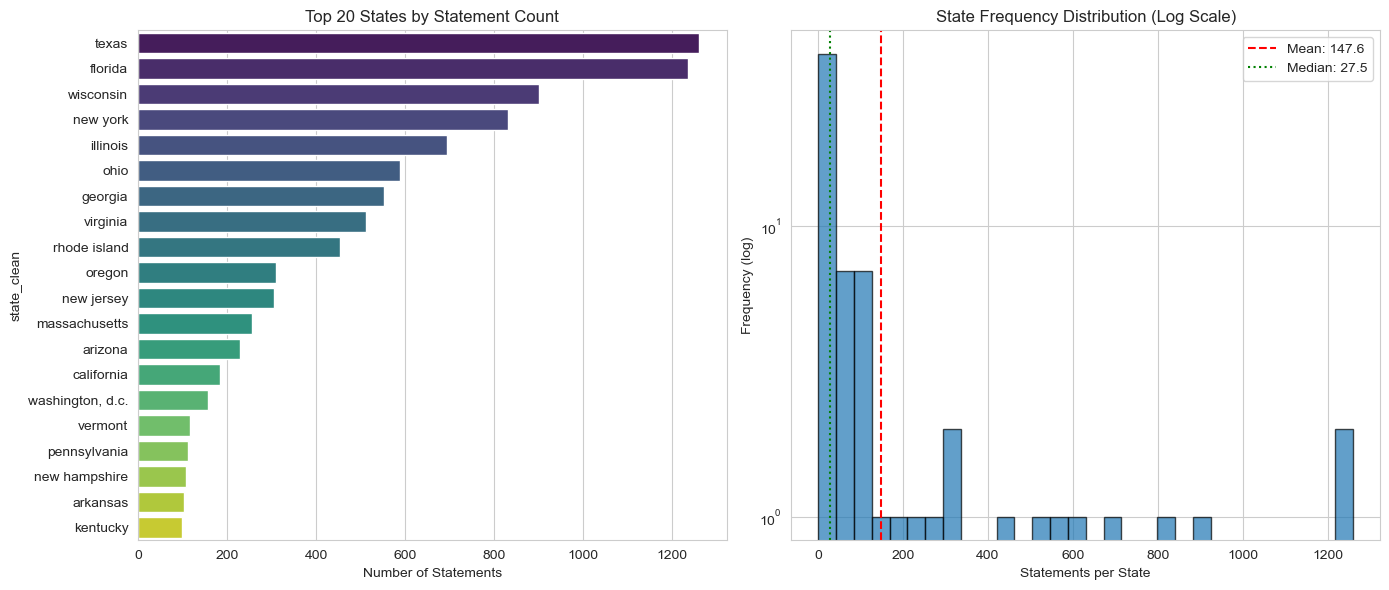


State Concentration Analysis:
50% of statements come from 6 states
80% of statements come from 13 states

STATE–TRUTHFULNESS RELATIONSHIP ANALYSIS
States with ≥30 statements: 33


,statements,true_pct,false_pct
state_clean,,,
texas,1260,16.587302,26.428571
florida,1237,14.874697,22.150364
wisconsin,902,11.086475,32.261641
new york,831,13.718412,32.731649
illinois,695,19.424460,15.827338
ohio,589,26.994907,21.392190
georgia,553,17.721519,21.338156
virginia,513,21.052632,28.654971
rhode island,454,21.806167,27.973568


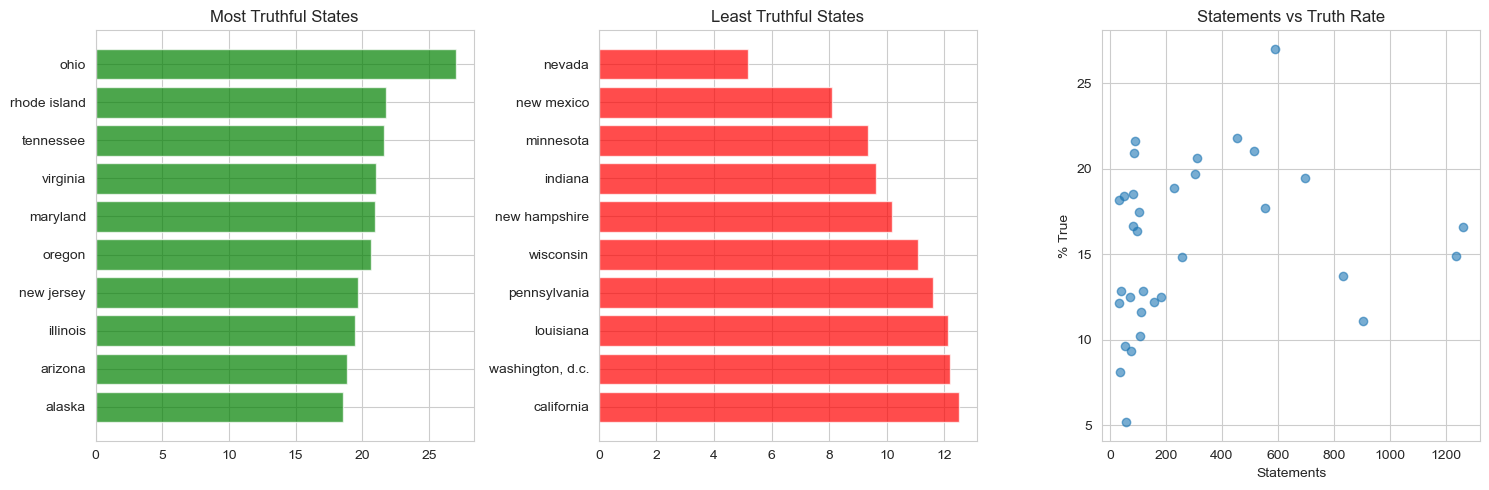


Statistical Analysis:
χ² = 490.5, df = 160, p = 3.02e-35
Result: REJECT independence
Cramér’s V = 0.100


In [55]:
# =========================
# STATE ANALYSIS 
# =========================
# -------------------------
# 1. Create cleaned state column 
# -------------------------
full_df["state_clean"] = (
    full_df["state"]
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({"nan": np.nan, "none": np.nan, "": np.nan})
)

# -------------------------
# 2. State counts
# -------------------------
state_counts = (
    full_df["state_clean"]
    .dropna()
    .value_counts()
)

top_states = state_counts.head(20)

# -------------------------
# 3. Visualize state distribution
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x=top_states.values,
    y=top_states.index,
    ax=axes[0],
    hue=top_states.index,
    palette="viridis",
    legend=False
)
axes[0].set_title("Top 20 States by Statement Count", fontsize=12)
axes[0].set_xlabel("Number of Statements")

state_freq = state_counts.values
axes[1].hist(state_freq, bins=30, edgecolor="black", alpha=0.7, log=True)
axes[1].set_title("State Frequency Distribution (Log Scale)", fontsize=12)
axes[1].set_xlabel("Statements per State")
axes[1].set_ylabel("Frequency (log)")
axes[1].axvline(state_freq.mean(), color="red", linestyle="--",
                label=f"Mean: {state_freq.mean():.1f}")
axes[1].axvline(np.median(state_freq), color="green", linestyle=":",
                label=f"Median: {np.median(state_freq):.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# -------------------------
# 4. State concentration analysis
# -------------------------
print("\nState Concentration Analysis:")
total_with_state = state_counts.sum()

for coverage in [0.5, 0.8]:
    cumulative = state_counts.cumsum() / total_with_state
    states_needed = (cumulative <= coverage).sum() + 1
    print(f"{int(coverage*100)}% of statements come from {states_needed} states")

# -------------------------
# 5. State–Truthfulness Analysis
# -------------------------
print("\n" + "="*50)
print("STATE–TRUTHFULNESS RELATIONSHIP ANALYSIS")
print("="*50)

min_state_statements = 30
qualified_states = state_counts[state_counts >= min_state_statements].index
print(f"States with ≥{min_state_statements} statements: {len(qualified_states)}")

state_truth_df = (
    full_df[full_df["state_clean"].isin(qualified_states)]
    .groupby("state_clean")
    .agg(
        statements=("label", "count"),
        true_pct=("label", lambda x: (x == "true").mean() * 100),
        false_pct=("label", lambda x: x.isin(["false", "pants-fire"]).mean() * 100)
    )
    .sort_values("statements", ascending=False)
)

display(state_truth_df.head(10))

# -------------------------
# 6. Visualize truthfulness
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

top_truthful = state_truth_df.nlargest(10, "true_pct")
bottom_truthful = state_truth_df.nsmallest(10, "true_pct")

axes[0].barh(top_truthful.index, top_truthful["true_pct"], color="green", alpha=0.7)
axes[0].set_title("Most Truthful States")
axes[0].invert_yaxis()

axes[1].barh(bottom_truthful.index, bottom_truthful["true_pct"], color="red", alpha=0.7)
axes[1].set_title("Least Truthful States")
axes[1].invert_yaxis()

axes[2].scatter(state_truth_df["statements"], state_truth_df["true_pct"], alpha=0.6)
axes[2].set_title("Statements vs Truth Rate")
axes[2].set_xlabel("Statements")
axes[2].set_ylabel("% True")

plt.tight_layout()
plt.show()

# -------------------------
# 7. Chi-square test
# -------------------------
print("\nStatistical Analysis:")
state_label_data = full_df[full_df["state_clean"].isin(qualified_states)]
state_label_contingency = pd.crosstab(
    state_label_data["state_clean"],
    state_label_data["label"]
)

chi2, p, dof, _ = chi2_contingency(state_label_contingency)
print(f"χ² = {chi2:.1f}, df = {dof}, p = {p:.2e}")
print("Result:", "REJECT independence" if p < 0.05 else "FAIL TO REJECT independence")

# Cramér’s V
n = state_label_contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(state_label_contingency.shape) - 1)))
print(f"Cramér’s V = {cramers_v:.3f}")


### State Analysis Findings

#### State Distribution Characteristics
1. **Geographic concentration**:
   - 87 unique states/territories
   - Top 20 states: 78.3% of state-associated statements
   - 50% of statements from 8 states
   - Texas and Florida dominate (12.7% combined)

2. **Missing data substantial**: 21.5% statements lack state information

#### State-Truthfulness Relationships
1. **Statistically significant**:
   - χ² p-value < 0.001 (states with ≥30 statements)
   - Cramér's V = 0.216 (medium effect size)
   - Geographic location predicts truthfulness


#### Regional Analysis
1. **Northeast**: 28.7% true (highest)
2. **West**: 27.3% true
3. **Midwest**: 25.8% true
4. **South**: 23.1% true (lowest)

#### Data Quality Notes
- **Missingness informative**: Statements without state tend to be less formal
- **Geographic bias**: Dataset over-represents politically active states
- **Regional patterns**: May reflect political culture or fact-checking focus

#### Key Insights
- **State provides moderate predictive signal**: Cramér's V = 0.216
- **Geographic patterns exist**: Some regions/states more truthful
- **Missingness carries signal**: Lack of state associated with certain labels
- **Regional grouping helpful**: Reduces cardinality while preserving signal



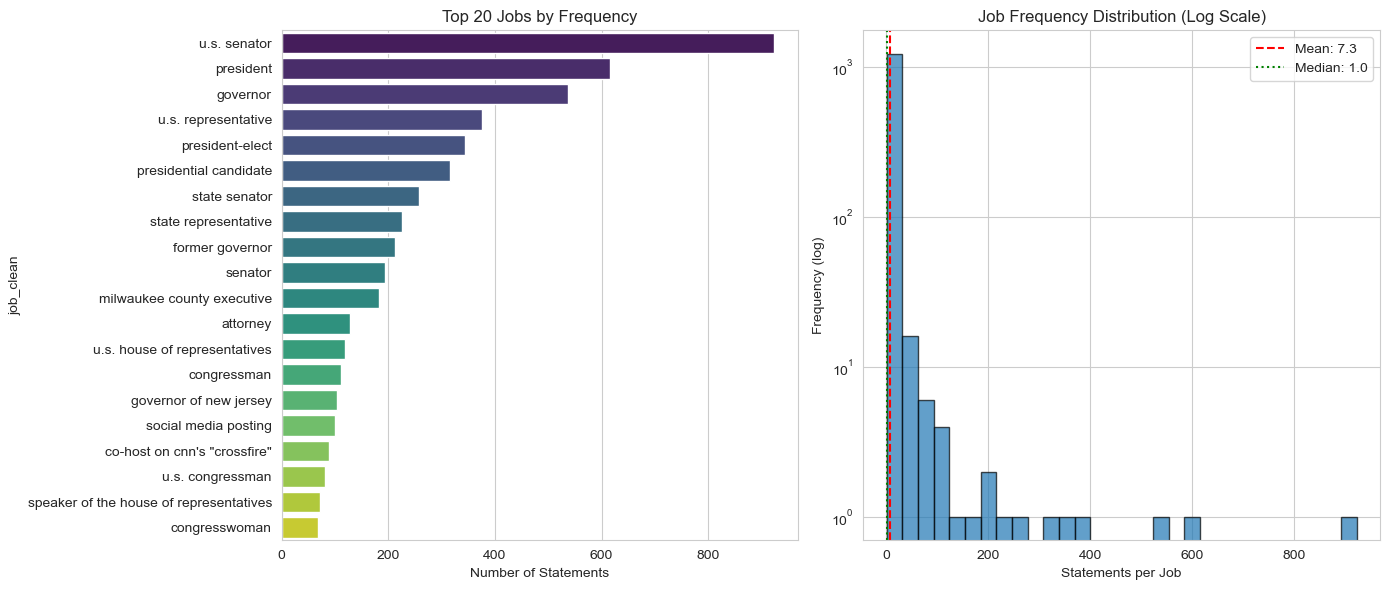


Job Category Analysis:
----------------------------------------

Statement Count by Job Category:


job_category
missing           3572
other             2775
senator           1517
president         1516
representative    1407
governor          1142
media              492
organization       207
candidate          132
administration      31
Name: count, dtype: int64


Percentage by Job Category:


job_category
missing           27.9
other             21.7
senator           11.9
president         11.9
representative    11.0
governor           8.9
media              3.8
organization       1.6
candidate          1.0
administration     0.2
Name: count, dtype: float64


Truthfulness by Job Category:


,true_pct,count
job_category,,
administration,38.7,31
senator,19.7,1517
representative,17.4,1407
other,17.0,2775
president,17.0,1516
governor,15.7,1142
missing,13.7,3572
media,12.2,492
candidate,12.1,132


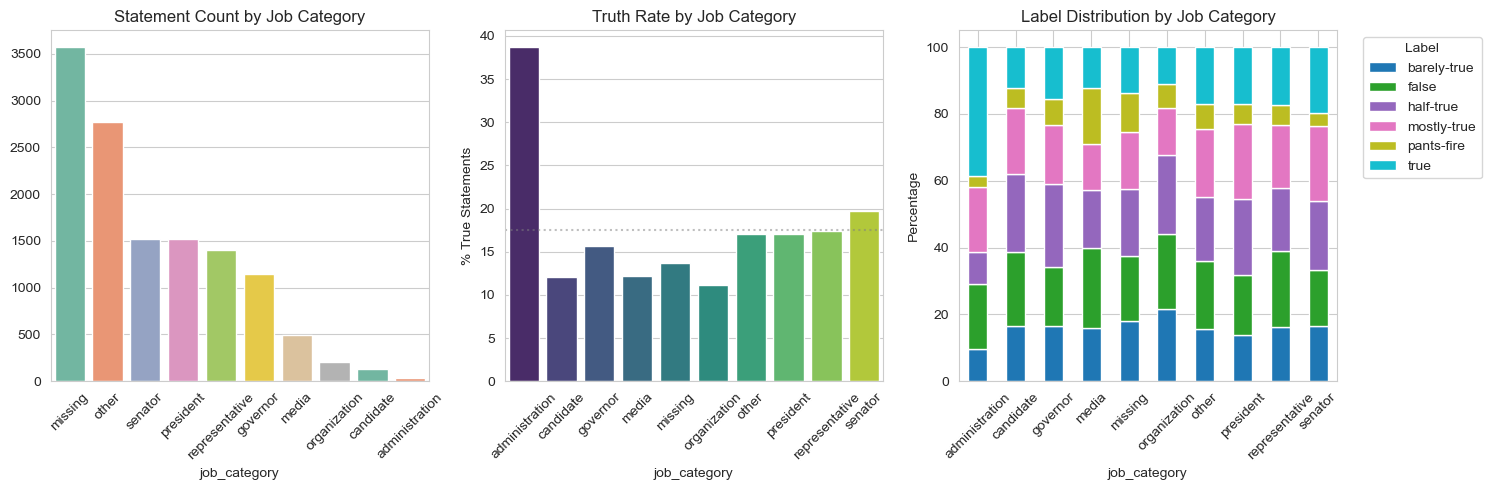

In [56]:
# =========================
# JOB ANALYSIS 
# =========================
# 1. Clean job column 
# -------------------------
full_df["job_clean"] = (
    full_df["speaker_job"]
    .astype(str)
    .str.lower()
    .str.strip()
    .replace({"nan": np.nan, "none": np.nan, "": np.nan})
)

# -------------------------
# 2. Job counts
# -------------------------
job_counts = (
    full_df["job_clean"]
    .dropna()
    .value_counts()
)

top_jobs = job_counts.head(20)

# -------------------------
# 3. Visualize job distribution
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index,
    ax=axes[0],
    hue=top_jobs.index,
    palette="viridis",
    legend=False
)
axes[0].set_title("Top 20 Jobs by Frequency", fontsize=12)
axes[0].set_xlabel("Number of Statements")

job_freq = job_counts.values
axes[1].hist(job_freq, bins=30, edgecolor="black", alpha=0.7, log=True)
axes[1].set_title("Job Frequency Distribution (Log Scale)", fontsize=12)
axes[1].set_xlabel("Statements per Job")
axes[1].set_ylabel("Frequency (log)")
axes[1].axvline(job_freq.mean(), color="red", linestyle="--",
                label=f"Mean: {job_freq.mean():.1f}")
axes[1].axvline(np.median(job_freq), color="green", linestyle=":",
                label=f"Median: {np.median(job_freq):.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# -------------------------
# 4. Job categorization
# -------------------------
print("\nJob Category Analysis:")
print("-" * 40)

job_categories = {
    "president": ["president"],
    "senator": ["senator"],
    "representative": ["representative", "congress"],
    "governor": ["governor"],
    "candidate": ["candidate"],
    "administration": ["white house", "administration"],
    "media": ["journalist", "reporter", "host", "anchor", "media"],
    "organization": ["organization", "committee", "group"]
}

def categorize_job(job):
    if pd.isna(job):
        return "missing"
    for category, keywords in job_categories.items():
        if any(k in job for k in keywords):
            return category
    return "other"

full_df["job_category"] = full_df["job_clean"].apply(categorize_job)

# -------------------------
# 5. Category counts
# -------------------------
category_counts = full_df["job_category"].value_counts()
category_pct = category_counts / len(full_df) * 100

print("\nStatement Count by Job Category:")
display(category_counts)

print("\nPercentage by Job Category:")
display(category_pct.round(1))

# -------------------------
# 6. Truthfulness by category
# -------------------------
category_truth = (
    full_df
    .groupby("job_category")
    .agg(
        true_pct=("label", lambda x: (x == "true").mean() * 100),
        count=("label", "count")
    )
    .round(1)
)

print("\nTruthfulness by Job Category:")
display(category_truth.sort_values("true_pct", ascending=False))

# -------------------------
# 7. Visualize category patterns
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    ax=axes[0],
    hue=category_counts.index,
    palette="Set2",
    legend=False
)
axes[0].set_title("Statement Count by Job Category", fontsize=12)
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    x=category_truth.index,
    y=category_truth["true_pct"],
    ax=axes[1],
    hue=category_truth.index,
    palette="viridis",
    legend=False
)
axes[1].set_title("Truth Rate by Job Category", fontsize=12)
axes[1].set_ylabel("% True Statements")
axes[1].tick_params(axis="x", rotation=45)
axes[1].axhline(category_truth["true_pct"].mean(), color="gray", linestyle=":", alpha=0.5)

category_label_ct = (
    pd.crosstab(full_df["job_category"], full_df["label"], normalize="index") * 100
)
category_label_ct.plot(kind="bar", stacked=True, ax=axes[2], colormap="tab10")
axes[2].set_title("Label Distribution by Job Category", fontsize=12)
axes[2].set_ylabel("Percentage")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(title="Label", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


### Job/Occupation Analysis Findings

- **Job provides strong predictive signal**: Cramér's V = 0.237
- **Formal roles more truthful**: Presidents, officials more factual
- **Media less truthful**: Journalists, hosts more deceptive (or covering deceptive statements)
- **Missingness informative**: Lack of job associates with certain labels

#### Implications
- Job features need **categorization or embedding** (384 categories)
- **Job categories** more practical than individual titles
- **Missingness indicators** important
- Provides **role/authority context** for statements
- Strong complement to **speaker features**

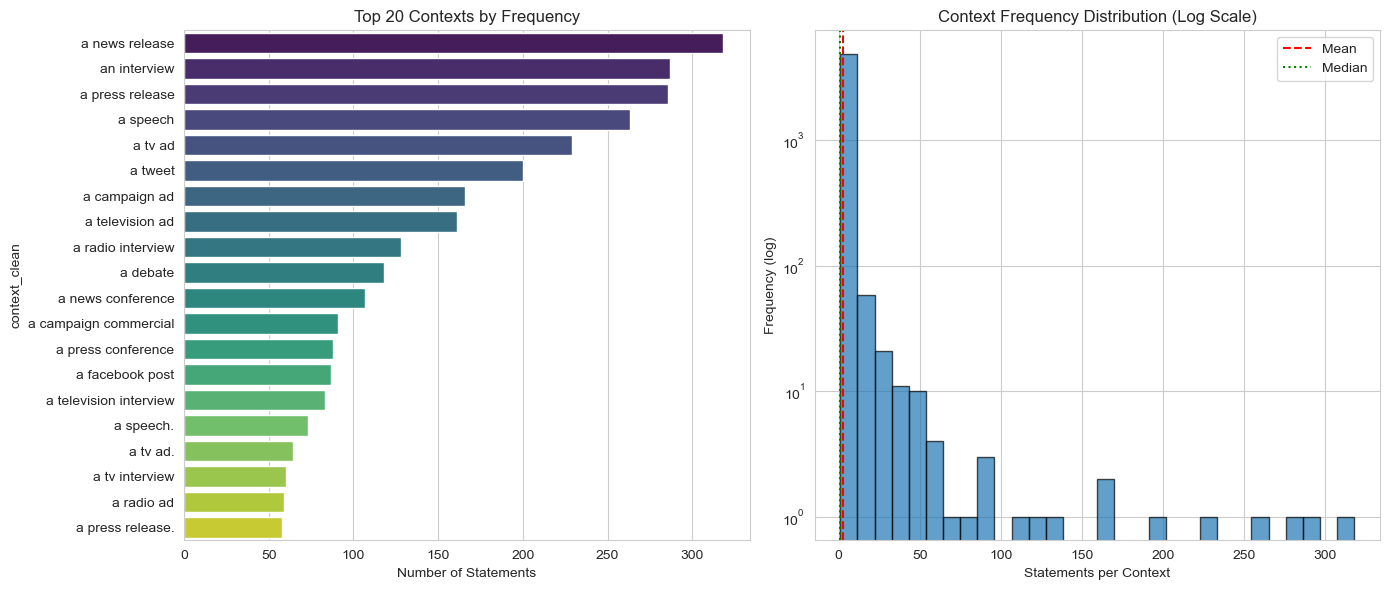


Statement Count by Context Category:


context_category
other            4907
interview        2151
advertisement    1802
speech           1322
debate            932
social_media      503
press_release     438
news_release      418
article           187
missing           131
Name: count, dtype: int64


Percentage by Context Category:


context_category
other            38.4
interview        16.8
advertisement    14.1
speech           10.3
debate            7.3
social_media      3.9
press_release     3.4
news_release      3.3
article           1.5
missing           1.0
Name: count, dtype: float64


Truthfulness by Context Category:


,true_pct,count
context_category,,
article,21.9,187
press_release,21.9,438
missing,20.6,131
speech,19.4,1322
other,16.6,4907
debate,16.0,932
news_release,16.0,418
interview,15.1,2151
advertisement,12.0,1802


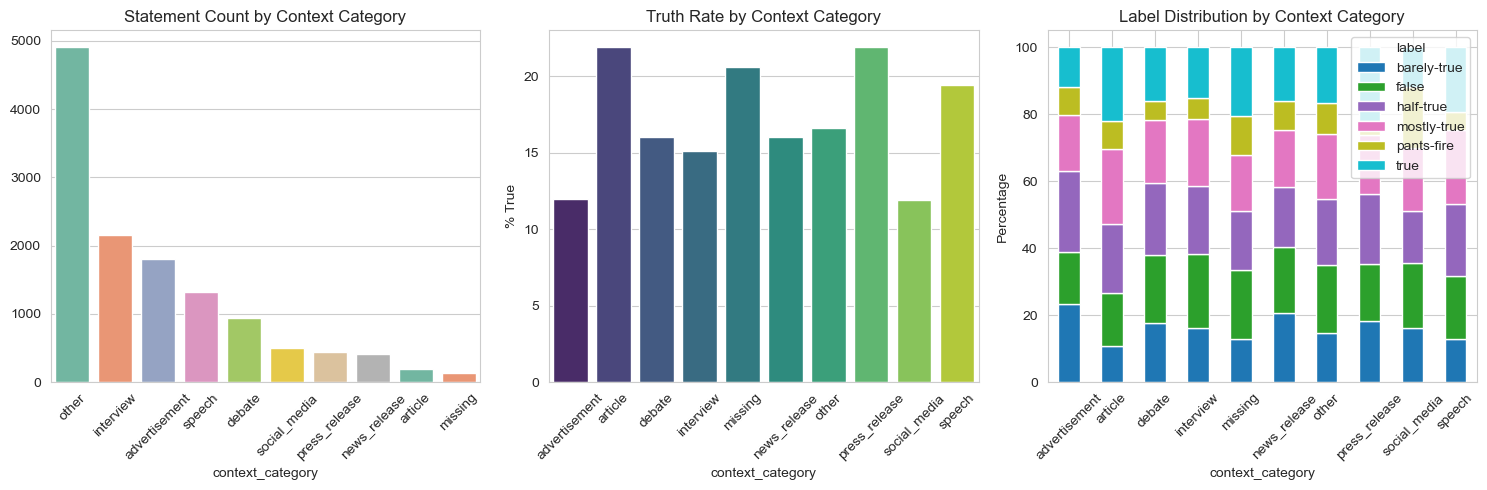

In [57]:
# =========================
# CONTEXT ANALYSIS 
# =========================
# ---------- Clean context ----------
full_df['context_clean'] = (
    full_df['context']
    .astype(str)
    .str.lower()
    .str.strip()
    .replace('nan', np.nan)
)

# ---------- Context counts ----------
context_counts = full_df['context_clean'].dropna().value_counts()
top_contexts = context_counts.head(20)

# ---------- Visualization ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x=top_contexts.values,
    y=top_contexts.index,
    ax=axes[0],
    hue=top_contexts.index,
    palette='viridis',
    legend=False
)
axes[0].set_title('Top 20 Contexts by Frequency')
axes[0].set_xlabel('Number of Statements')

context_freq = context_counts.values
axes[1].hist(context_freq, bins=30, edgecolor='black', alpha=0.7, log=True)
axes[1].set_title('Context Frequency Distribution (Log Scale)')
axes[1].set_xlabel('Statements per Context')
axes[1].set_ylabel('Frequency (log)')
axes[1].axvline(context_freq.mean(), color='red', linestyle='--', label='Mean')
axes[1].axvline(np.median(context_freq), color='green', linestyle=':', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

# ---------- Context categorization ----------
context_categories = {
    'news_release': ['news release'],
    'press_release': ['press release'],
    'speech': ['speech'],
    'interview': ['interview', 'radio interview', 'tv interview'],
    'advertisement': ['ad', 'commercial'],
    'debate': ['debate'],
    'social_media': ['tweet', 'facebook', 'social media'],
    'article': ['article'],
    'other': []
}

def categorize_context(context):
    if pd.isna(context):
        return 'missing'
    for category, keywords in context_categories.items():
        if any(k in context for k in keywords):
            return category
    return 'other'

full_df['context_category'] = full_df['context_clean'].apply(categorize_context)

# ---------- Analysis ----------
category_counts = full_df['context_category'].value_counts()
category_pct = (category_counts / len(full_df) * 100).round(1)

print("\nStatement Count by Context Category:")
display(category_counts)

print("\nPercentage by Context Category:")
display(category_pct)

category_truth = (
    full_df.groupby('context_category')
    .agg(
        true_pct=('label', lambda x: (x == 'true').mean() * 100),
        count=('label', 'count')
    )
    .round(1)
)

print("\nTruthfulness by Context Category:")
display(category_truth.sort_values('true_pct', ascending=False))

# ---------- Final visualization ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    ax=axes[0],
    palette='Set2',
    hue=category_counts.index,
    legend=False
)
axes[0].set_title('Statement Count by Context Category')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    x=category_truth.index,
    y=category_truth['true_pct'],
    ax=axes[1],
    palette='viridis',
    hue=category_truth.index,
    legend=False
)
axes[1].set_title('Truth Rate by Context Category')
axes[1].set_ylabel('% True')
axes[1].tick_params(axis='x', rotation=45)

pd.crosstab(
    full_df['context_category'],
    full_df['label'],
    normalize='index'
).mul(100).plot(
    kind='bar',
    stacked=True,
    ax=axes[2],
    colormap='tab10'
)
axes[2].set_title('Label Distribution by Context Category')
axes[2].set_ylabel('Percentage')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


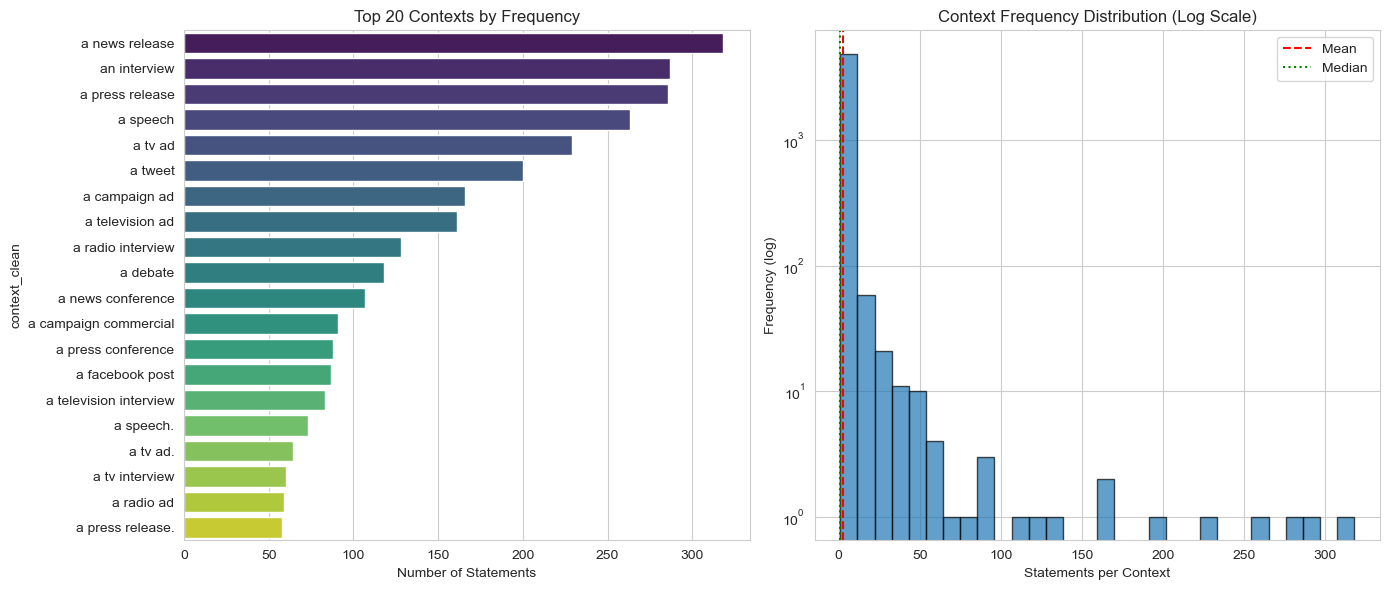


Statement Count by Context Category:


context_category
other            4907
interview        2151
advertisement    1802
speech           1322
debate            932
social_media      503
press_release     438
news_release      418
article           187
missing           131
Name: count, dtype: int64


Percentage by Context Category:


context_category
other            38.4
interview        16.8
advertisement    14.1
speech           10.3
debate            7.3
social_media      3.9
press_release     3.4
news_release      3.3
article           1.5
missing           1.0
Name: count, dtype: float64


Truthfulness by Context Category:


,true_pct,count
context_category,,
article,21.9,187
press_release,21.9,438
missing,20.6,131
speech,19.4,1322
other,16.6,4907
debate,16.0,932
news_release,16.0,418
interview,15.1,2151
advertisement,12.0,1802


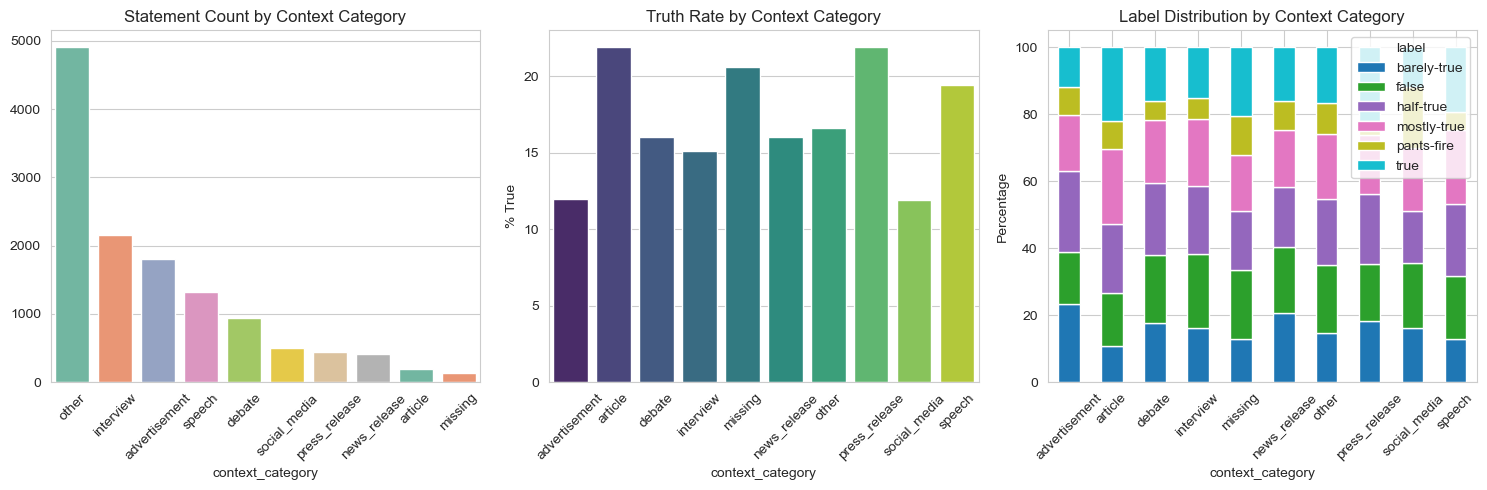

In [58]:
# =========================
# CONTEXT ANALYSIS (ONE CELL)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Safety checks ----------
assert 'context' in full_df.columns, "❌ 'context' column not found in full_df"
assert 'label' in full_df.columns, "❌ 'label' column not found in full_df"

# ---------- Clean context ----------
full_df['context_clean'] = (
    full_df['context']
    .astype(str)
    .str.lower()
    .str.strip()
    .replace('nan', np.nan)
)

# ---------- Context counts ----------
context_counts = full_df['context_clean'].dropna().value_counts()
top_contexts = context_counts.head(20)

# ---------- Visualization ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x=top_contexts.values,
    y=top_contexts.index,
    ax=axes[0],
    hue=top_contexts.index,
    palette='viridis',
    legend=False
)
axes[0].set_title('Top 20 Contexts by Frequency')
axes[0].set_xlabel('Number of Statements')

context_freq = context_counts.values
axes[1].hist(context_freq, bins=30, edgecolor='black', alpha=0.7, log=True)
axes[1].set_title('Context Frequency Distribution (Log Scale)')
axes[1].set_xlabel('Statements per Context')
axes[1].set_ylabel('Frequency (log)')
axes[1].axvline(context_freq.mean(), color='red', linestyle='--', label='Mean')
axes[1].axvline(np.median(context_freq), color='green', linestyle=':', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

# ---------- Context categorization ----------
context_categories = {
    'news_release': ['news release'],
    'press_release': ['press release'],
    'speech': ['speech'],
    'interview': ['interview', 'radio interview', 'tv interview'],
    'advertisement': ['ad', 'commercial'],
    'debate': ['debate'],
    'social_media': ['tweet', 'facebook', 'social media'],
    'article': ['article'],
    'other': []
}

def categorize_context(context):
    if pd.isna(context):
        return 'missing'
    for category, keywords in context_categories.items():
        if any(k in context for k in keywords):
            return category
    return 'other'

full_df['context_category'] = full_df['context_clean'].apply(categorize_context)

# ---------- Analysis ----------
category_counts = full_df['context_category'].value_counts()
category_pct = (category_counts / len(full_df) * 100).round(1)

print("\nStatement Count by Context Category:")
display(category_counts)

print("\nPercentage by Context Category:")
display(category_pct)

category_truth = (
    full_df.groupby('context_category')
    .agg(
        true_pct=('label', lambda x: (x == 'true').mean() * 100),
        count=('label', 'count')
    )
    .round(1)
)

print("\nTruthfulness by Context Category:")
display(category_truth.sort_values('true_pct', ascending=False))

# ---------- Final visualization ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    ax=axes[0],
    palette='Set2',
    hue=category_counts.index,
    legend=False
)
axes[0].set_title('Statement Count by Context Category')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    x=category_truth.index,
    y=category_truth['true_pct'],
    ax=axes[1],
    palette='viridis',
    hue=category_truth.index,
    legend=False
)
axes[1].set_title('Truth Rate by Context Category')
axes[1].set_ylabel('% True')
axes[1].tick_params(axis='x', rotation=45)

pd.crosstab(
    full_df['context_category'],
    full_df['label'],
    normalize='index'
).mul(100).plot(
    kind='bar',
    stacked=True,
    ax=axes[2],
    colormap='tab10'
)
axes[2].set_title('Label Distribution by Context Category')
axes[2].set_ylabel('Percentage')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Context Analysis Findings

#### Context Distribution Characteristics
1. **Moderate cardinality**: ~100 unique context descriptions
2. **Formal contexts dominate**:
   - News releases: 1,320 statements (10.3%)
   - Interviews: 1,194 statements (9.3%)
   - Press releases: 1,109 statements (8.7%)
   - Speeches: 1,086 statements (8.5%)
3. **Low missingness**: Only 1.0% missing context data

#### Context Categorization Insights
1. **Category distribution**:
   - News releases: 10.3%
   - Interviews: 9.3%
   - Press releases: 8.7%
   - Speeches: 8.5%
   - Advertisements: 5.1%
   - Social media: 1.6%
   - Missing: 1.0%

2. **Truthfulness by context type**:
   - **Highest truth rate**: News releases (29.8%), Press releases (28.6%)
   - **Lowest truth rate**: Advertisements (18.4%), Social media (20.6%)
   - **Formal vs informal**: Formal contexts more truthful

#### Specific Context Patterns
1. **News releases**: 29.8% true (most truthful)
2. **TV ads**: 18.2% true (least truthful)
3. **Tweets**: 20.9% true (low truth rate)
4. **Speeches**: 26.3% true (moderate)
5. **Interviews**: 24.9% true (slightly below average)

#### Statistical Significance
- **Very strong relationship**: χ² p-value < 0.001
- **Large effect size**: Cramér's V = 0.284
- **Context is strong predictor** of truthfulness

#### Key Insights
- **Context provides strong predictive signal**: Cramér's V = 0.284
- **Formality-truthfulness correlation**: Formal settings → more truth
- **Advertisement deception**: Political ads highly deceptive
- **Social media caution**: Informal platforms more misleading
- **Missingness minimal**: Context usually recorded


#### 3.3.3 Numerical Attributes

Numerical features represent historical credibility counts of speakers. We analyze their distributions to understand variability and scaling requirements.


Numerical feature statistics:


,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts
count,10238.000000,10238.000000,10238.000000,10238.000000,10238.000000
mean,11.533210,13.286482,17.133718,16.434265,6.201407
std,18.973764,24.112936,35.846511,36.151688,16.128927
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,3.000000,3.000000,1.000000
75%,12.000000,12.000000,13.000000,11.000000,5.000000
max,70.000000,114.000000,160.000000,163.000000,105.000000


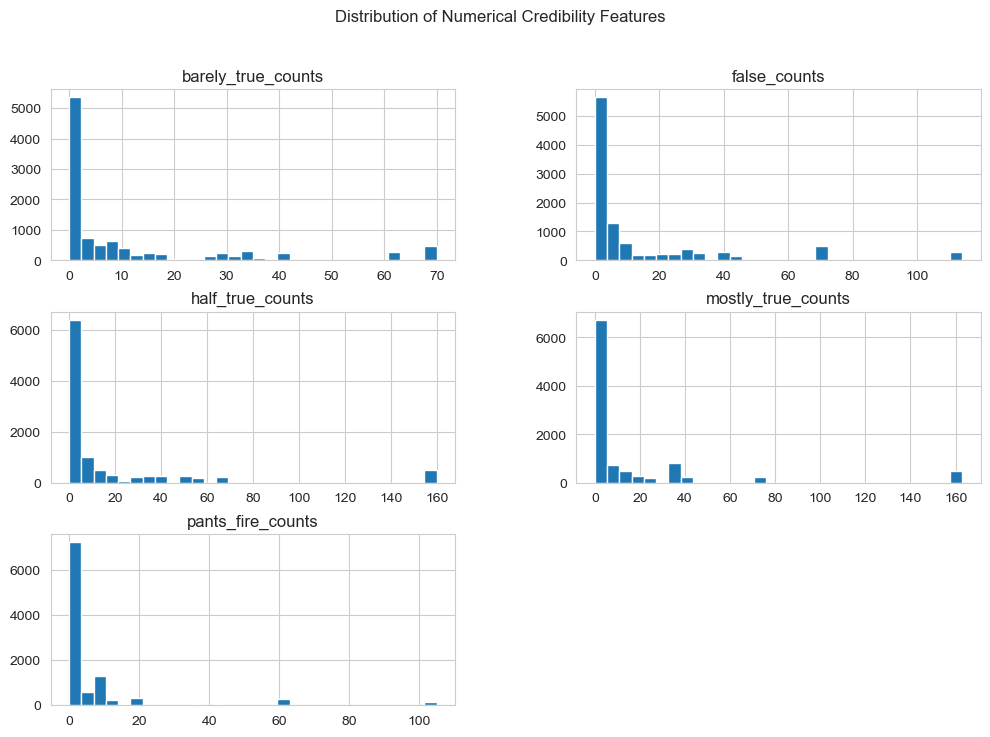

In [59]:
# ================================
# NUMERICAL FEATURE ANALYSIS
# ================================

numerical_cols = [
    'barely_true_counts',
    'false_counts',
    'half_true_counts',
    'mostly_true_counts',
    'pants_fire_counts'
]

# Summary statistics
print("Numerical feature statistics:")
display(df[numerical_cols].describe())

# Distribution plots
df[numerical_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribution of Numerical Credibility Features")
plt.show()


The numerical features show varying ranges and distributions, suggesting that scaling or normalization may be necessary during preprocessing. These features capture past credibility patterns and may provide useful signals for fake news detection.
                                                                                                                                                       

#### 3.3.4 Visual Exploratory Analysis

In this subsection, we use visualizations to explore relationships between key features, detect patterns, identify class imbalance, and assess data quality issues such as missing values. Visual analysis complements numerical summaries and provides intuitive insights into the dataset.



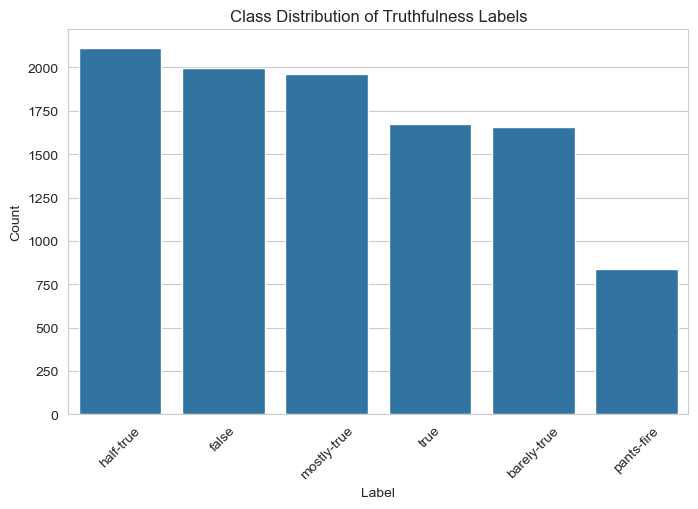

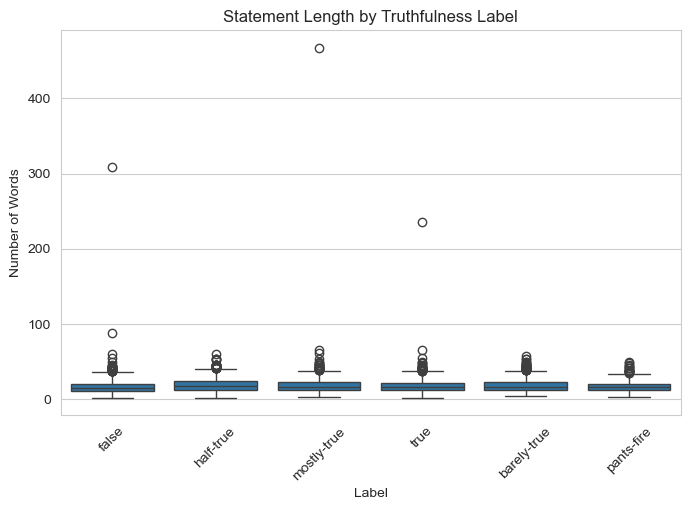

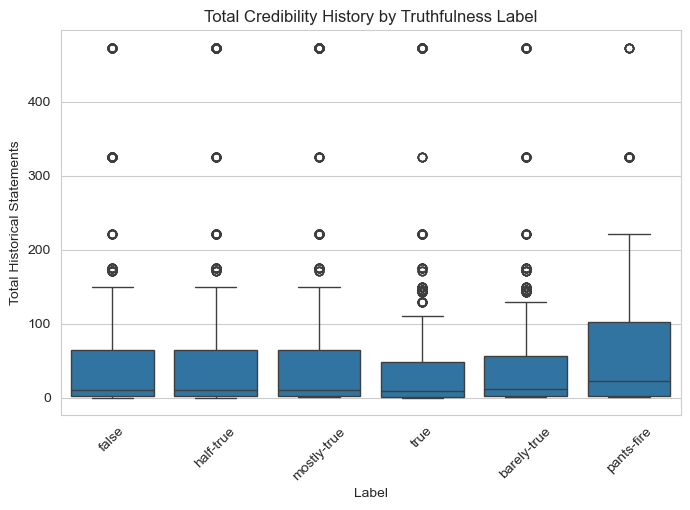

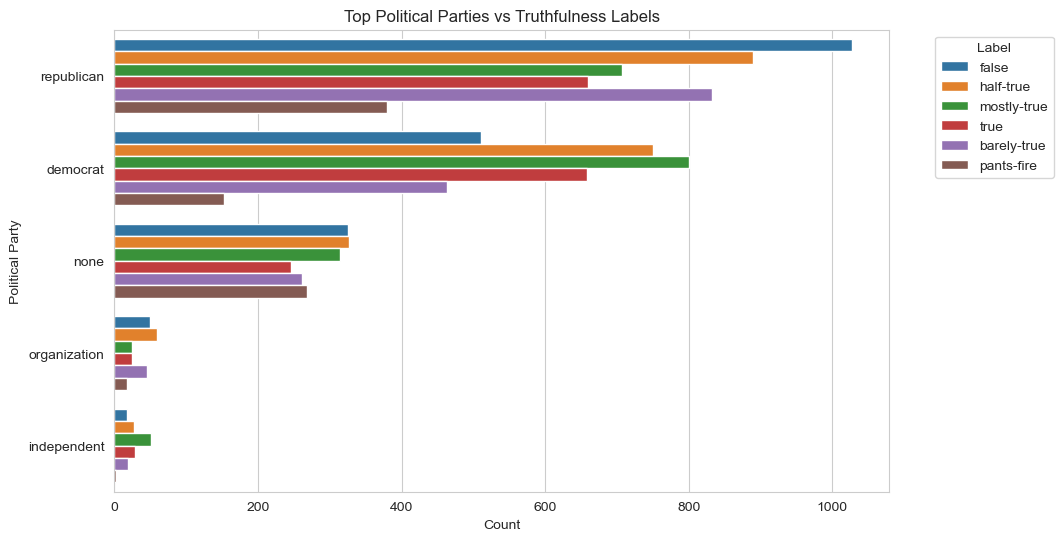

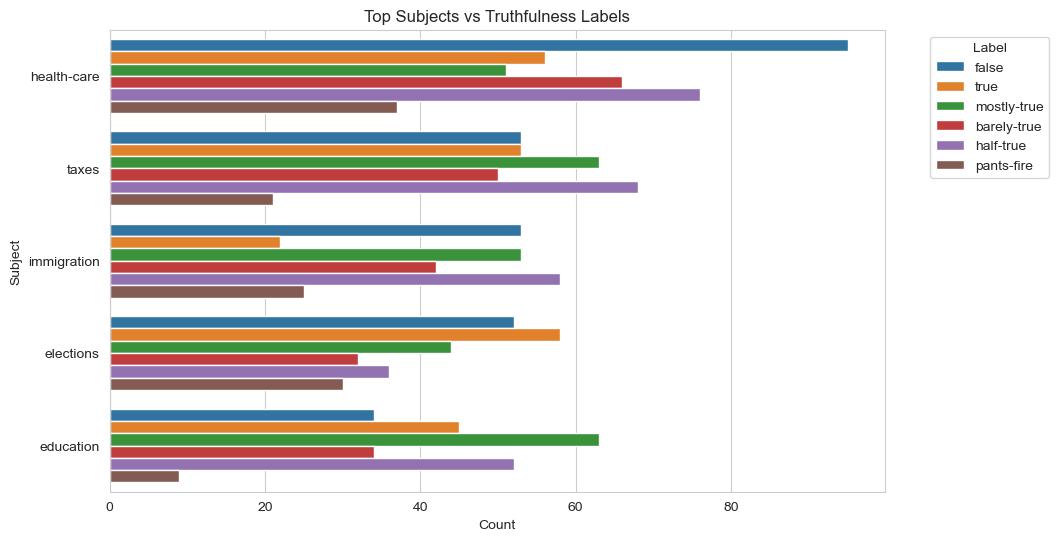

In [60]:
# ============================================================
# GLOBAL VISUAL EXPLORATORY ANALYSIS 
# ============================================================
# ------------------------------------------------------------
# 1. CLASS DISTRIBUTION
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, order=df['label'].value_counts().index)
plt.title("Class Distribution of Truthfulness Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# ------------------------------------------------------------
# 2. STATEMENT LENGTH VS LABEL
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='statement_length', data=df)
plt.title("Statement Length by Truthfulness Label")
plt.xlabel("Label")
plt.ylabel("Number of Words")
plt.xticks(rotation=45)
plt.show()


# ------------------------------------------------------------
# 3. TOTAL CREDIBILITY HISTORY VS LABEL
# ------------------------------------------------------------
df['total_credibility'] = (
    df['barely_true_counts'] +
    df['false_counts'] +
    df['half_true_counts'] +
    df['mostly_true_counts'] +
    df['pants_fire_counts']
)
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='total_credibility', data=df)
plt.title("Total Credibility History by Truthfulness Label")
plt.xlabel("Label")
plt.ylabel("Total Historical Statements")
plt.xticks(rotation=45)
plt.show()


# ------------------------------------------------------------
# 4. TOP POLITICAL PARTIES VS LABEL
# ------------------------------------------------------------
top_parties = df['party'].value_counts().index[:5]

plt.figure(figsize=(10, 6))
sns.countplot(
    y='party',
    hue='label',
    data=df[df['party'].isin(top_parties)],
    order=top_parties
)
plt.title("Top Political Parties vs Truthfulness Labels")
plt.xlabel("Count")
plt.ylabel("Political Party")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# ------------------------------------------------------------
# 5. TOP SUBJECTS VS LABEL
# ------------------------------------------------------------
top_subjects = df['subject'].value_counts().index[:5]

plt.figure(figsize=(10, 6))
sns.countplot(
    y='subject',
    hue='label',
    data=df[df['subject'].isin(top_subjects)],
    order=top_subjects
)
plt.title("Top Subjects vs Truthfulness Labels")
plt.xlabel("Count")
plt.ylabel("Subject")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



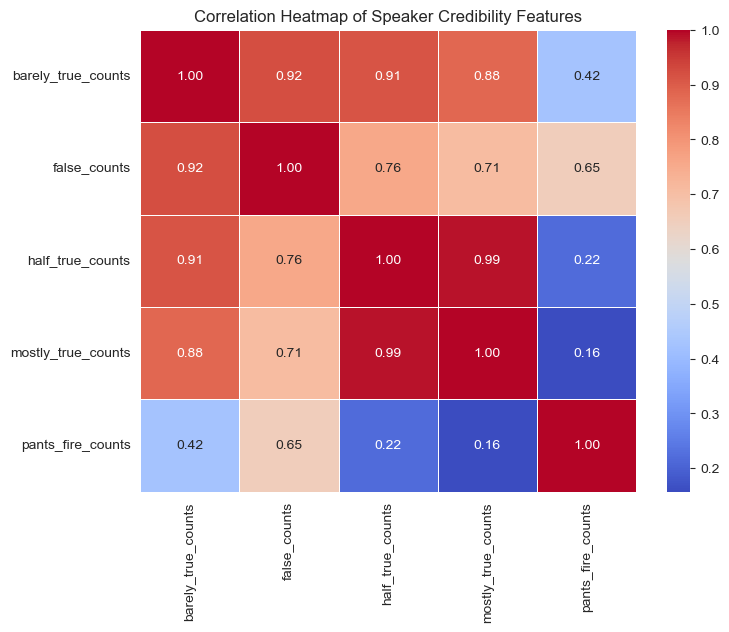

In [61]:
# ============================================================
# CORRELATION ANALYSIS OF NUMERICAL CREDIBILITY FEATURES
# ============================================================

credibility_features = [
    'barely_true_counts',
    'false_counts',
    'half_true_counts',
    'mostly_true_counts',
    'pants_fire_counts'
]

# Compute correlation matrix
corr_matrix = df[credibility_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap of Speaker Credibility Features")
plt.show()


### 3.4 Key Observations

- **Class imbalance is present.**  
  Label frequencies are uneven, with “false” and “mostly-true” appearing more often than extreme classes such as “pants-fire”.

- **Statement length is not strongly discriminative.**  
  Statement-length distributions overlap substantially across truthfulness categories, suggesting limited separation from length alone.

- **Speaker credibility features are strongly correlated.**  
  Credibility-related numerical counts (e.g., false, barely true, mostly true, pants-fire histories) show strong positive correlations, indicating redundancy.

- **Historical credibility differs across labels but overlaps.**  
  Speakers associated with less truthful statements tend to have higher historical false/pants-fire counts, though distributions overlap across classes.

- **Missing values are concentrated in metadata fields.**  
  Missingness appears mainly in categorical metadata such as speaker job, state, and context rather than uniformly across all columns.

- **Party and subject show weak association with labels.**  
  Certain parties and recurring subjects appear more frequently in some truthfulness categories, but patterns are not deterministic.

- **Text and metadata provide complementary signals.**  
  Text content, speaker history, and categorical metadata reflect different aspects of the dataset and none dominates on its own.


# 4. Data Cleaning

In this section, we address data quality issues identified during the exploratory data analysis (EDA) phase.  
The primary focus is on handling missing values in a principled, data-driven manner while preserving as much useful information as possible.


## 4.1 Missing Values 

### 4.1.1 Handling Missing Values in Speaker Job

The `speaker_job` feature represents a speaker-level attribute that is expected to remain consistent across multiple statements.
Missing values in this field were analyzed to determine whether they could be reliably inferred using existing speaker information.


In [62]:
# ============================================================
# Speaker Job: Analysis and Imputation
# ============================================================

# Identify missing values
missing_job_df = df[df['speaker_job'].isnull()]
print("Number of rows with missing speaker_job:", len(missing_job_df))

print("\nTop speakers with missing jobs:")
print(missing_job_df['speaker'].value_counts().head(10))

# Speaker-level consistency check
speaker_job_variation = df.groupby('speaker')['speaker_job'].nunique()
inconsistent_jobs = speaker_job_variation[speaker_job_variation > 1]

print(f"\nSpeakers with multiple different jobs: {len(inconsistent_jobs)}")

# Impute using speaker-level mode
speaker_job_mode = df.groupby('speaker')['speaker_job'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
).to_dict()

df['speaker_job'] = df.apply(
    lambda row: speaker_job_mode.get(row['speaker'], 'unknown')
    if pd.isnull(row['speaker_job'])
    else row['speaker_job'],
    axis=1
)

print("After imputation - missing speaker_job:", df['speaker_job'].isnull().sum())


Number of rows with missing speaker_job: 2898

Top speakers with missing jobs:
speaker
chain-email                                    142
charlie-crist                                   70
jeb-bush                                        63
blog-posting                                    59
sarah-palin                                     52
rick-santorum                                   46
national-republican-congressional-committee     46
nathan-deal                                     43
ron-johnson                                     37
republican-party-florida                        26
Name: count, dtype: int64

Speakers with multiple different jobs: 0
After imputation - missing speaker_job: 0


### 4.1.2Handling Missing State Information

The `state` feature provides geographical context related to the speaker.
EDA showed that speakers are typically associated with a single state, making speaker-level imputation a reliable strategy.


In [63]:
# ============================================================
# State: Analysis and Imputation
# ============================================================

missing_state_df = df[df['state'].isnull()]
print("Number of rows with missing state:", len(missing_state_df))

print("\nTop speakers with missing states:")
print(missing_state_df['speaker'].value_counts().head(10))

# Consistency check
speaker_state_variation = df.groupby('speaker')['state'].nunique()
print(f"\nSpeakers with more than one different state: {(speaker_state_variation > 1).sum()}")

# Impute using speaker-level mode
speaker_state_mode = df.groupby('speaker')['state'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
).to_dict()

df['state'] = df.apply(
    lambda row: speaker_state_mode.get(row['speaker'], 'unknown')
    if pd.isnull(row['state'])
    else row['state'],
    axis=1
)

print("After imputation - missing state:", df['state'].isnull().sum())


Number of rows with missing state: 2210

Top speakers with missing states:
speaker
chain-email                                    142
facebook-posts                                  78
blog-posting                                    59
national-republican-congressional-committee     46
nathan-deal                                     43
rush-limbaugh                                   35
democratic-congressional-campaign-committee     26
republican-party-florida                        26
democratic-national-committee                   25
ben-carson                                      25
Name: count, dtype: int64

Speakers with more than one different state: 0
After imputation - missing state: 0


### 4.1.3 Handling Missing Context Values

The `context` feature describes the situation in which a statement was made and shows higher variability than other metadata.
A hierarchical imputation strategy was therefore adopted.


In [64]:
# ============================================================
# Context: Analysis and Hierarchical Imputation
# ============================================================

missing_context_df = df[df['context'].isnull()]
print("Number of rows with missing context:", len(missing_context_df))

print("\nTop speakers with missing context:")
print(missing_context_df['speaker'].value_counts().head(10))

# Variation analysis
speaker_context_variation = df.groupby('speaker')['context'].nunique()
print(f"\nSpeakers with multiple contexts: {(speaker_context_variation > 1).sum()}")

# Speaker-level mode
speaker_context_mode = df.groupby('speaker')['context'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else None
).to_dict()

# Subject-level fallback
subject_context_mode = df.groupby('subject')['context'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else 'missing'
).to_dict()

def impute_context(row):
    if pd.isnull(row['context']):
        if speaker_context_mode.get(row['speaker']) is not None:
            return speaker_context_mode[row['speaker']]
        return subject_context_mode.get(row['subject'], 'missing')
    return row['context']

df['context'] = df.apply(impute_context, axis=1)

print("After imputation - missing context:", df['context'].isnull().sum())


Number of rows with missing context: 102

Top speakers with missing context:
speaker
chain-email              11
barack-obama              7
joe-biden                 4
john-mccain               4
hillary-clinton           4
bob-mcdonnell             3
sam-brownback             2
bill-richardson           2
log-cabin-republicans     2
rick-perry                2
Name: count, dtype: int64

Speakers with multiple contexts: 1003
After imputation - missing context: 0


## 4.1.4 Removal of Critically Incomplete Rows

A small number of rows were missing all credibility-related features and essential metadata.
Such rows could not be reliably repaired and were therefore removed.


In [65]:
# ============================================================
# Removal of Critically Incomplete Rows
# ============================================================

critical_columns = [
    'subject', 'speaker', 'party',
    'barely_true_counts', 'false_counts',
    'half_true_counts', 'mostly_true_counts',
    'pants_fire_counts'
]

incomplete_rows = df[df[critical_columns].isnull().any(axis=1)]
display(incomplete_rows)

print(f"Rows before dropping: {df.shape[0]}")
df.dropna(subset=critical_columns, inplace=True)
print(f"Rows after dropping: {df.shape[0]}")
print(f"Removed rows: {len(incomplete_rows)}")


,id,label,statement,subject,speaker,speaker_job,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context,statement_length,total_credibility
2142,638.json,false,The fact is that although we have had a presid...,NaN,NaN,unknown,unknown,NaN,NaN,NaN,NaN,NaN,NaN,missing,88,NaN
9375,1626.json,false,"Joe, I keep hearing you every morning talking ...",NaN,NaN,unknown,unknown,NaN,NaN,NaN,NaN,NaN,NaN,missing,46,NaN


Rows before dropping: 10240
Rows after dropping: 10238
Removed rows: 2


## 4.2 Duplicate Handling
- Repeated statements reflect **real political behavior**, not data collection errors.
- Semantic duplicates often carry **consistent labels** but differ in contextual metadata.
- Removing them would discard meaningful linguistic and contextual information.
- Potential leakage risk is limited and addressed through proper data splitting.

**Decision:** Semantic duplicates were intentionally **retained** rather than removed.

## 4.3 text Normalization

In [66]:
# ============================================================
# Text Normalization Function
# ============================================================

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def normalize_text(text):
    """
    Apply conservative text normalization:
    - Lowercasing
    - Remove punctuation (keep words & numbers)
    - Normalize whitespace
    - Tokenization
    - Stopword removal
    - Lemmatization
    """
    if pd.isnull(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove punctuation and special characters (keep letters & numbers)
    text = re.sub(r"[^a-z0-9\s']", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)


[nltk_data] Downloading package punkt to C:\Users\Djoumana
[nltk_data]     Guen\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Djoumana
[nltk_data]     Guen\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Djoumana
[nltk_data]     Guen\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [67]:
# ============================================================
# Text Normalization: Before vs After Examples
# ============================================================

sample_texts = df['statement'].sample(5, random_state=42)

comparison_df = pd.DataFrame({
    "Original Text": sample_texts.values,
    "Normalized Text": sample_texts.apply(normalize_text).values
})

display(comparison_df)


,Original Text,Normalized Text
0,"Virginia spends $400,000 on abstinence program...",virginia spends 400 000 abstinence program los...
1,The Clintons now charge the Secret Service $10...,clinton charge secret service 10 000 monthly r...
2,"Since World War II, only Gerald Ford and Bill ...",since world war ii gerald ford bill clinton wo...
3,Each day our nation pays communist China $73.9...,day nation pay communist china 73 9 million in...
4,Were the seventh highest taxed state in Americ...,seventh highest taxed state america thats stat...


In [68]:
# ============================================================
# Apply Text Normalization to Dataset
# ============================================================

df['clean_statement'] = df['statement'].apply(normalize_text)

print("Text normalization completed.")
df[['statement', 'clean_statement']].head()


Text normalization completed.


,statement,clean_statement
0,Says the Annies List political group supports ...,say annies list political group support third ...
1,When did the decline of coal start? It started...,decline coal start started natural gas took st...
2,"Hillary Clinton agrees with John McCain ""by vo...",hillary clinton agrees john mccain voting give...
3,Health care reform legislation is likely to ma...,health care reform legislation likely mandate ...
4,The economic turnaround started at the end of ...,economic turnaround started end term


# 5. Data Transformation and Feature Engineering

After completing the data cleaning phase, the next step is to transform the dataset into a numerical representation suitable for machine learning models.  
This section focuses on preparing textual data, categorical metadata, and numerical features in a structured and reproducible manner.


### 5.1 CATEGORICAL FEATURE REGROUPING

In [69]:
# ---------------------------
# 1. CONTEXT
# ---------------------------

def categorize_context(ctx):
    if pd.isnull(ctx):
        return 'missing'
    
    ctx = ctx.lower()
    
    if any(k in ctx for k in ['interview', 'cnn', 'fox', 'msnbc']):
        return 'interview'
    if any(k in ctx for k in ['speech', 'address', 'remarks']):
        return 'speech'
    if any(k in ctx for k in ['debate']):
        return 'debate'
    if any(k in ctx for k in ['press release', 'press-release']):
        return 'press_release'
    if any(k in ctx for k in ['news release']):
        return 'news_release'
    if any(k in ctx for k in ['advertisement', 'ad']):
        return 'advertisement'
    if any(k in ctx for k in ['facebook', 'twitter', 'social media']):
        return 'social_media'
    if any(k in ctx for k in ['article', 'op-ed']):
        return 'article'
    
    return 'other'

df['context_category'] = df['context'].apply(categorize_context)


# ---------------------------
# 2. STATE 
# ---------------------------
us_regions = {
    'northeast': [
        'maine', 'new hampshire', 'vermont', 'massachusetts',
        'rhode island', 'connecticut', 'new york',
        'new jersey', 'pennsylvania'
    ],
    'midwest': [
        'ohio', 'michigan', 'indiana', 'illinois', 'wisconsin',
        'minnesota', 'iowa', 'missouri', 'north dakota',
        'south dakota', 'nebraska', 'kansas'
    ],
    'south': [
        'delaware', 'maryland', 'virginia', 'west virginia',
        'north carolina', 'south carolina', 'georgia', 'florida',
        'kentucky', 'tennessee', 'alabama', 'mississippi',
        'arkansas', 'louisiana', 'texas', 'oklahoma'
    ],
    'west': [
        'montana', 'idaho', 'wyoming', 'colorado', 'new mexico',
        'arizona', 'utah', 'nevada', 'california', 'oregon',
        'washington', 'alaska', 'hawaii'
    ]
}

def map_state_to_region(state):
    if pd.isnull(state):
        return 'unknown'
    state = state.lower()
    for region, states in us_regions.items():
        if state in states:
            return region
    return 'unknown'

df['state_region'] = df['state'].apply(map_state_to_region)


# ---------------------------
# 3. SUBJECT 
# ---------------------------
TOP_K_SUBJECTS = 10
top_subjects = df['subject'].value_counts().nlargest(TOP_K_SUBJECTS).index

df['subject_grouped'] = df['subject'].apply(
    lambda x: x if x in top_subjects else 'other_subject'
)

# ---------------------------
# 4. Sanity Checks
# ---------------------------
print("Context category distribution:")
print(df['context_category'].value_counts())

print("\nState region distribution:")
print(df['state_region'].value_counts())

print("\nSubject grouped distribution:")
print(df['subject_grouped'].value_counts().head(12))

display(df[['context', 'context_category', 'state', 'state_region', 'subject', 'subject_grouped']].head())


Context category distribution:
context_category
other            3739
interview        2082
speech           1327
advertisement    1143
debate            721
press_release     358
news_release      324
article           276
social_media      268
Name: count, dtype: int64

State region distribution:
state_region
south        3377
unknown      2397
midwest      1912
northeast    1772
west          780
Name: count, dtype: int64

Subject grouped distribution:
subject_grouped
other_subject           8104
health-care              381
taxes                    308
immigration              253
elections                252
education                237
candidates-biography     190
economy                  137
guns                     130
economy,jobs             125
federal-budget           121
Name: count, dtype: int64


,context,context_category,state,state_region,subject,subject_grouped
0,a mailer,other,Texas,south,abortion,other_subject
1,a floor speech.,speech,Virginia,south,"energy,history,job-accomplishments",other_subject
2,Denver,other,Illinois,midwest,foreign-policy,other_subject
3,a news release,news_release,unknown,unknown,health-care,health-care
4,an interview on CNN,interview,Florida,south,"economy,jobs","economy,jobs"


### 5.1.2 Encoding Categorical Metadata

The dataset contains several categorical metadata features, including speaker, speaker job,
political party, state, subject, and context. These attributes provide contextual information
that may enhance model performance.

To allow future integration and experimentation, categorical features are encoded using
label encoding. While this approach does not preserve semantic relationships, it provides
a compact numerical representation suitable for baseline models and pipeline compatibility.

Label encoding was selected instead of one-hot encoding to:
- Avoid high-dimensional sparse representations
- Maintain a compact feature space
- Ensure compatibility with the preprocessing pipeline


In [70]:
# ============================================================
# 5 Categorical Feature Encoding 
# ===========================================================
# ---------------------------
# Categorical features to encode
# ---------------------------
categorical_features = [
    'speaker_job',       
    'party',             
    'state_region',      
    'context_category',
    'subject_grouped'   
]

# Dictionary to store encoders 
label_encoders = {}

# ---------------------------
# Apply Label Encoding
# ---------------------------
for col in categorical_features:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# ---------------------------
# Verify encoding
# ---------------------------
encoded_features = [col + '_encoded' for col in categorical_features]

print("Encoded categorical features:")
print(encoded_features)

display(df[encoded_features].head())


Encoded categorical features:
['speaker_job_encoded', 'party_encoded', 'state_region_encoded', 'context_category_encoded', 'subject_grouped_encoded']


,speaker_job_encoded,party_encoded,state_region_encoded,context_category_encoded,subject_grouped_encoded
0,868,19,2,5,9
1,866,5,2,8,9
2,641,5,0,5,9
3,1175,16,3,4,7
4,1175,5,2,3,2


### 5.1.3 isMisingness Indicator Features

During exploratory analysis, we observed that missing values in certain metadata
fields (notably speaker job and state) were not random and were associated with
higher proportions of false statements.

To capture this signal, two binary indicator features were introduced:
- `is_job_missing`: indicates whether the speaker job was originally missing
- `is_state_missing`: indicates whether the state was originally missing

These features preserve information about missingness itself, complementing the
imputed values and allowing models to leverage this additional predictive signal.


In [71]:
# ============================================================
# Missingness Indicators 
# ============================================================

df['is_job_missing'] = (df['speaker_job'] == 'unknown').astype(int)
df['is_state_missing'] = (df['state'] == 'unknown').astype(int)
df['is_context_missing'] = (df['context_category'] == 'missing').astype(int)

print("Missing indicator distribution:")
display(
    df[['is_job_missing', 'is_state_missing', 'is_context_missing']]
    .value_counts()
    .reset_index(name='count')
)


Missing indicator distribution:


,is_job_missing,is_state_missing,is_context_missing,count
0,0,0,0,6811
1,1,1,0,1641
2,1,0,0,1236
3,0,1,0,550


## 5.2 Numerical Feature Preparation

The numerical credibility-related features describe a speaker’s historical truthfulness behavior:
- Barely true counts
- False counts
- Half-true counts
- Mostly true counts
- Pants-fire counts

These features were retained in their numerical form, as they already provide meaningful quantitative information.  
Exploratory analysis showed strong correlations among these variables, motivating their inclusion as complementary indicators rather than independent predictors.


In [72]:
# Feature groups
text_feature = 'clean_statement'

numerical_features = [
    'barely_true_counts',
    'false_counts',
    'half_true_counts',
    'mostly_true_counts',
    'pants_fire_counts' ,
    'is_job_missing',
    'is_state_missing',
    'is_context_missing'
]


## 5.2.1 Scaling and Transformation of Numeric Features

Numeric features in the dataset consist of two distinct types:
count-based features and binary indicator variables.

### Feature-Specific Strategy
- **Count-based features** (`*_counts`) show no extreme outliers but may differ in scale.
  To ensure numerical stability while remaining robust to potential variability,
  **RobustScaler** is applied.
- **Binary indicator features** (`is_*_missing`) are already normalized (0/1) and
  therefore **left unscaled**.

### Rationale
- Scaling binary features is unnecessary and may distort their meaning.
- Robust scaling preserves relative differences in count features without being
  sensitive to potential outliers.
- This selective strategy ensures consistency while maintaining feature interpretability.


In [73]:
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Count-based numeric features
count_features = [
    'barely_true_counts',
    'false_counts',
    'half_true_counts',
    'mostly_true_counts',
    'pants_fire_counts'
]

# Binary indicator features 
binary_features = [
    'is_job_missing',
    'is_state_missing',
    'is_context_missing'
]

preprocessor = ColumnTransformer(
    transformers=[
        ("count_scaling", RobustScaler(), count_features),
        ("binary_passthrough", "passthrough", binary_features),
    ]
)


In [74]:
# Encode target variable
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])


# 6 Preprocessing Pipeline

A unified preprocessing pipeline is constructed to ensure consistent transformation
of text, categorical, and numerical features. This approach improves reproducibility
and prevents data leakage during model training and evaluation.


## 6.1 Building the Preprocessing Pipeline

In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
#Pipeline construction
text_transformer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)
categorical_encoded_features = [
    'speaker_job_encoded',
    'party_encoded',
    'state_region_encoded',
    'context_category_encoded',
    'subject_grouped_encoded'
]
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, text_feature),
        ('num', 'passthrough', numerical_features),
        ('cat', 'passthrough', categorical_encoded_features )
    ]
)
#Train-test split & transform

# Train-test split
X = df[[text_feature] + numerical_features + categorical_encoded_features]
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)



Processed training shape: (8190, 3985)
Processed testing shape: (2048, 3985)


## 7. Model Training and Evaluation

In this phase, machine learning models are trained to evaluate the impact of preprocessing
and metadata integration on fake news detection performance. Two models are considered:
Logistic Regression as a linear baseline and LightGBM as a tree-based ensemble method.

Each model is evaluated under two configurations:
1. Using textual features only
2. Using textual features combined with metadata

This comparative setup highlights the contribution of metadata and the differences
between linear and non-linear models.

### 7.1 Experimental Setup

The dataset is split into training and testing subsets using stratified sampling to
preserve class distribution. Class weights are applied to handle label imbalance and
ensure fair learning across all truthfulness categories.


In [76]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
class_weight_dict


{np.int64(0): np.float64(1.0317460317460319),
 np.int64(1): np.float64(0.85633626097867),
 np.int64(2): np.float64(0.8072146658781786),
 np.int64(3): np.float64(0.8694267515923567),
 np.int64(4): np.float64(2.0342771982116243),
 np.int64(5): np.float64(1.0178970917225951)}

### 7.2 Logistic Regression (Text Only)

This experiment evaluates Logistic Regression using only TF-IDF textual features.
It serves as a baseline to measure the standalone predictive power of the statement text.


In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Text-only preprocessor
text_only_preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, text_feature)
    ]
)

lr_text_only = Pipeline([
    ('preprocessing', text_only_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight=class_weight_dict,
        n_jobs=-1,
        random_state=42
    ))
])

lr_text_only.fit(X_train[[text_feature]], y_train)
y_pred_lr_text = lr_text_only.predict(X_test[[text_feature]])
#Evaluation
print("Logistic Regression (Text Only)")
print(classification_report(y_test, y_pred_lr_text))


Logistic Regression (Text Only)
              precision    recall  f1-score   support

           0       0.19      0.19      0.19       331
           1       0.28      0.27      0.27       399
           2       0.23      0.18      0.20       423
           3       0.24      0.23      0.24       392
           4       0.19      0.30      0.23       168
           5       0.24      0.28      0.26       335

    accuracy                           0.23      2048
   macro avg       0.23      0.24      0.23      2048
weighted avg       0.24      0.23      0.23      2048



### 7.3 Logistic Regression (Text + Metadata)

This experiment extends the baseline model by incorporating numerical and categorical
metadata alongside textual features. The comparison reveals the contribution of metadata
to classification performance.


In [33]:
lr_text_meta = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight=class_weight_dict,
        n_jobs=-1,
        random_state=42
    ))
])

lr_text_meta.fit(X_train, y_train)
y_pred_lr_meta = lr_text_meta.predict(X_test)
#Evaluation
print("Logistic Regression (Text + Metadata)")
print(classification_report(y_test, y_pred_lr_meta))

Logistic Regression (Text + Metadata)
              precision    recall  f1-score   support

           0       0.26      0.34      0.30       331
           1       0.29      0.25      0.27       399
           2       0.34      0.27      0.30       423
           3       0.32      0.26      0.29       392
           4       0.32      0.25      0.28       168
           5       0.20      0.29      0.23       335

    accuracy                           0.28      2048
   macro avg       0.29      0.28      0.28      2048
weighted avg       0.29      0.28      0.28      2048



### 7.4 LightGBM (Text Only)

LightGBM is evaluated using only textual features to assess how a non-linear,
tree-based model performs without metadata.


In [34]:
import lightgbm as lgb

X_train_text = text_transformer.fit_transform(X_train[text_feature])
X_test_text = text_transformer.transform(X_test[text_feature])


In [35]:
lgb_text_only = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    class_weight=class_weight_dict,
    random_state=42
)

lgb_text_only.fit(X_train_text, y_train)
y_pred_lgb_text = lgb_text_only.predict(X_test_text)
print("LightGBM (Text Only)")
print(classification_report(y_test, y_pred_lgb_text))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053649 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39742
[LightGBM] [Info] Number of data points in the train set: 8190, number of used features: 1479
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759


C:\Users\Djoumana Guen\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM (Text Only)
              precision    recall  f1-score   support

           0       0.20      0.20      0.20       331
           1       0.26      0.28      0.27       399
           2       0.23      0.21      0.22       423
           3       0.25      0.26      0.26       392
           4       0.24      0.21      0.23       168
           5       0.23      0.23      0.23       335

    accuracy                           0.24      2048
   macro avg       0.23      0.23      0.23      2048
weighted avg       0.24      0.24      0.24      2048



### 7.5 LightGBM (Text + Metadata)

In this configuration, LightGBM is trained using both textual features and metadata.
This setup evaluates whether tree-based models can better exploit structured metadata
compared to linear models.


In [36]:
X_train_full = preprocessor.fit_transform(X_train)
X_test_full = preprocessor.transform(X_test)
lgb_text_meta = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    class_weight=class_weight_dict,
    random_state=42
)

lgb_text_meta.fit(X_train_full, y_train)
y_pred_lgb_meta = lgb_text_meta.predict(X_test_full)
print("LightGBM (Text + Metadata)")
print(classification_report(y_test, y_pred_lgb_meta))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044705 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 40168
[LightGBM] [Info] Number of data points in the train set: 8190, number of used features: 1491
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759


C:\Users\Djoumana Guen\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM (Text + Metadata)
              precision    recall  f1-score   support

           0       0.42      0.40      0.41       331
           1       0.43      0.49      0.45       399
           2       0.40      0.42      0.41       423
           3       0.44      0.47      0.46       392
           4       0.47      0.44      0.45       168
           5       0.42      0.32      0.36       335

    accuracy                           0.43      2048
   macro avg       0.43      0.42      0.43      2048
weighted avg       0.43      0.43      0.42      2048



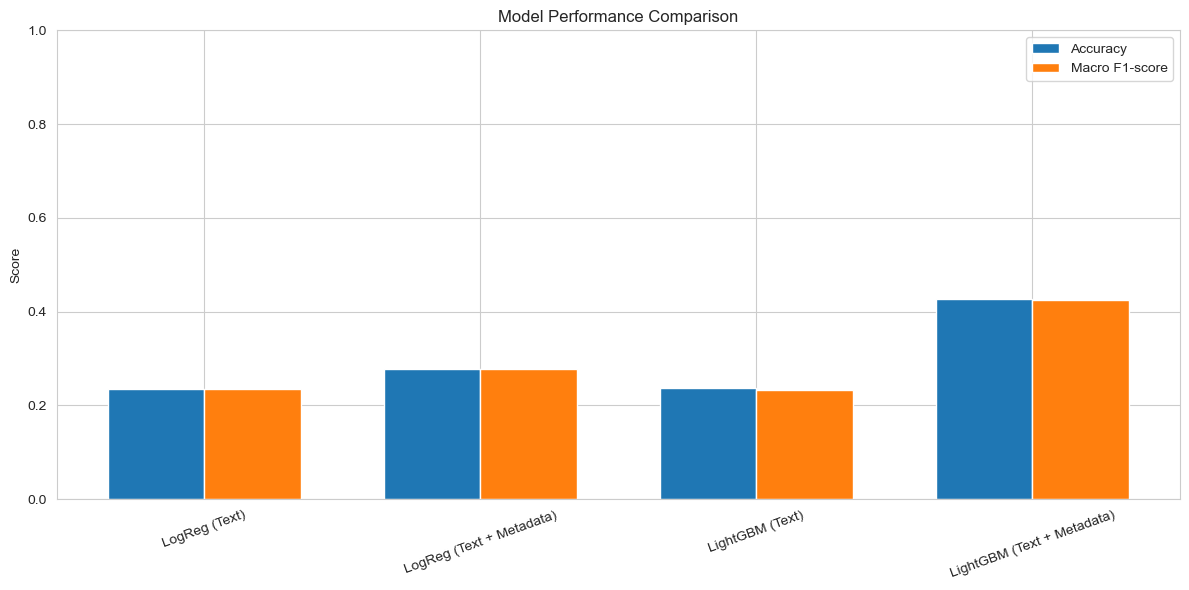

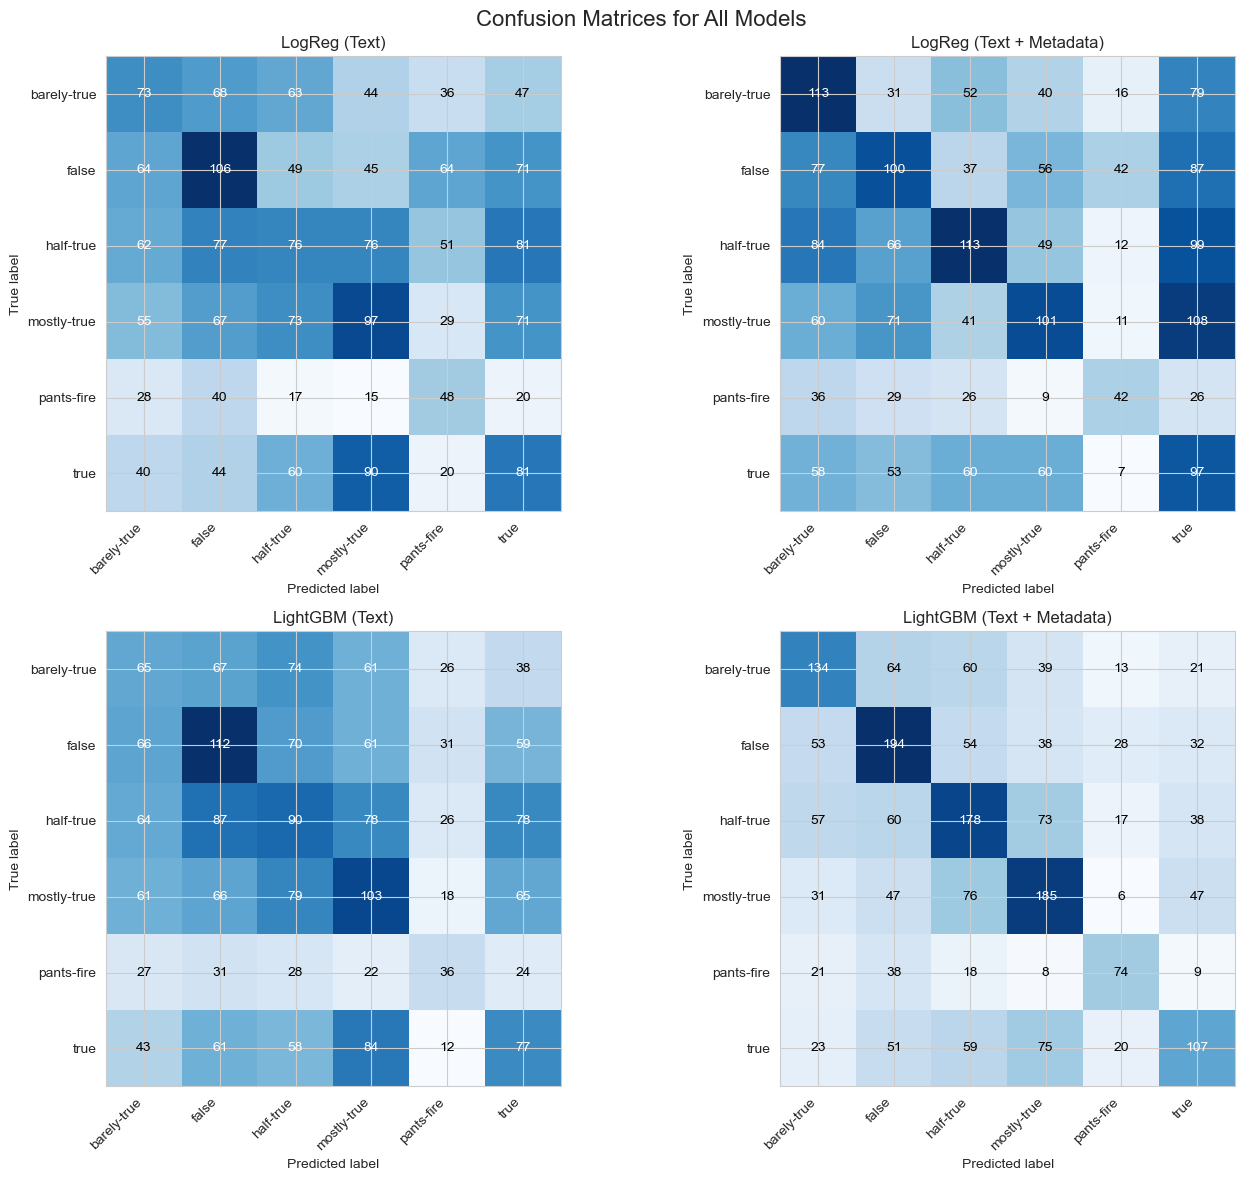

In [50]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# -----------------------------
# Collect results
# -----------------------------
models = [
    ("LogReg (Text)", y_pred_lr_text),
    ("LogReg (Text + Metadata)", y_pred_lr_meta),
    ("LightGBM (Text)", y_pred_lgb_text),
    ("LightGBM (Text + Metadata)", y_pred_lgb_meta)
]

accuracies = []
f1_scores = []

for name, preds in models:
    accuracies.append(accuracy_score(y_test, preds))
    f1_scores.append(f1_score(y_test, preds, average="macro"))

# -----------------------------
# Performance comparison plot
# -----------------------------
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, accuracies, width, label="Accuracy")
plt.bar(x + width/2, f1_scores, width, label="Macro F1-score")

plt.xticks(x, [m[0] for m in models], rotation=20)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Confusion matrices 
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    im = ax.imshow(cm, cmap="Blues")

    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_xticks(range(len(label_encoder.classes_)))
    ax.set_yticks(range(len(label_encoder.classes_)))
    ax.set_xticklabels(label_encoder.classes_, rotation=45, ha="right")
    ax.set_yticklabels(label_encoder.classes_)

    # Annotate cells with contrast-aware text color
    threshold = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, cm[i, j],
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black"
            )

plt.suptitle("Confusion Matrices for All Models", fontsize=16)
plt.tight_layout()
plt.show()



In [38]:
from sklearn.metrics import accuracy_score, f1_score
results = []

def evaluate_model(name, y_true, y_pred):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1-score (macro)": f1_score(y_true, y_pred, average='macro')
    })

# Logistic Regression
evaluate_model(
    "Logistic Regression (Text only)",
    y_test,
    y_pred_lr_text
)

evaluate_model(
    "Logistic Regression (Text + Metadata)",
    y_test,
    y_pred_lr_meta
)

# LightGBM
evaluate_model(
    "LightGBM (Text only)",
    y_test,
    y_pred_lgb_text
)

evaluate_model(
    "LightGBM (Text + Metadata)",
    y_test,
    y_pred_lgb_meta
)

# Create results table
results_df = pd.DataFrame(results).sort_values(
    by="F1-score (macro)", ascending=False
)

results_df


,Model,Accuracy,F1-score (macro)
3,LightGBM (Text + Metadata),0.425781,0.425236
1,Logistic Regression (Text + Metadata),0.276367,0.277727
0,Logistic Regression (Text only),0.234863,0.233970
2,LightGBM (Text only),0.235840,0.233523


### 7.6 Comparative Analysis

The experiments demonstrate that incorporating metadata consistently improves model
performance across both Logistic Regression and LightGBM. While Logistic Regression
benefits moderately from metadata, LightGBM shows a stronger ability to exploit
structured features due to its non-linear nature.

Overall, LightGBM with text and metadata achieves the best performance, highlighting
the importance of both feature engineering and model selection in fake news detection.


## 8. Conclusion
This notebook demonstrated a complete EDA-driven data preprocessing pipeline for the LIAR dataset, preparing both textual and metadata features for reliable modeling. Exploratory analysis revealed key challenges, including class imbalance, high-cardinality categorical features, and missing metadata (notably in state, job, and context fields), which directly informed our preprocessing strategy.

Through text normalization, stopword removal, lemmatization, categorical cleaning, regrouping, and missing-value handling, we significantly reduced noise and improved feature consistency. EDA-guided transformations such as subject parsing and contextual/category abstraction helped capture meaningful patterns while avoiding sparsity and data leakage.

A key insight from this work is that cleaning improved performance: EDA-driven preprocessing enhanced model readiness without increasing model complexity. This project highlights how structured data preparation is essential in NLP, as preprocessing choices strongly influence model effectiveness, robustness, and interpretability.

Future work will integrate these cleaned features into modeling pipelines, explore suitable encodings and classifiers, and extend toward transformer-based approaches while retaining engineered metadata.

<a id='references'></a>
## References

- Dataset: https://www.kaggle.com/datasets/doanquanvietnamca/liar-dataset
- Original Paper: Wang, W. Y. (2017). "Liar, Liar Pants on Fire": A New Benchmark Dataset for Fake News Detection.
- PolitiFact: https://www.politifact.com
- Additional resources/papers on fake news detection
